In [ ]:
# ==========================================
# 0. MOUNT GOOGLE DRIVE
# ==========================================
from google.colab import drive
import os

print("Mounting Google Drive...")
drive.mount('/content/drive')

Mounting Google Drive...
Mounted at /content/drive


In [ ]:
# ==========================================
# 1. IMPORT LIBRARIES
# ==========================================
import torch
import torch.nn as nn
from torchvision.models import efficientnet_b2
from torch.utils.data import DataLoader, Dataset # Pastikan Dataset di-import
from datasets import load_dataset
from torchvision import transforms
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_auc_score
import torch.nn.functional as F
import pandas as pd

# ==========================================
# 2. KONFIGURASI FOLDER & DEVICE
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Menggunakan device: {device}")

# Sesuaikan path ini dengan folder di Google Drive kamu
FOLDER_CLASS_WEIGHT = '/content/drive/MyDrive/Alzheimer_EfficientNet_Models'
FOLDER_SAMPLER      = '/content/drive/MyDrive/Alzheimer_EfficientNet_Models_Sampler'

# ==========================================
# 3. DEFINISI CLASS DATASET (WAJIB ADA)
# ==========================================
class AlzheimerDataset(Dataset):
    def __init__(self, hf_data, transform=None):
        self.data = hf_data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        image = item["image"].convert("RGB")
        label = item["label"]

        if self.transform:
            image = self.transform(image)

        return image, label

# ==========================================
# 4. PERSIAPAN DATA UJI (TEST DATASET)
# ==========================================
print("\nMenyiapkan Data Test...")
hf_dataset = load_dataset("Falah/Alzheimer_MRI")
test_data = hf_dataset["test"]

base_transform = transforms.Compose([
    transforms.Resize((260, 260)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Menggunakan class yang sudah didefinisikan di Step 3
test_ds = AlzheimerDataset(test_data, base_transform)
test_loader = DataLoader(test_ds, batch_size=16, shuffle=False, num_workers=2)

# ==========================================
# 5. INISIALISASI ARSITEKTUR MODEL
# ==========================================
print("\nMembangun arsitektur EfficientNet-B2...")
model = efficientnet_b2(weights=None)

# Custom classifier (harus sama persis dengan saat training!)
num_classes = 4
model.classifier = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(1408, 512),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(512, num_classes)
)
model = model.to(device)
model.eval()

# ==========================================
# 6. FUNGSI EVALUASI MASSAL
# ==========================================
def evaluate_models_in_folder(folder_path, method_name):
    results = []

    if not os.path.exists(folder_path):
        print(f"Folder tidak ditemukan: {folder_path}")
        return results

    model_files = [f for f in os.listdir(folder_path) if f.endswith('.pth')]
    model_files.sort()

    for filename in model_files:
        filepath = os.path.join(folder_path, filename)
        parts = filename.replace('.pth', '').split('_')

        try:
            scenario = parts[1]
            optimizer = parts[2]
            scheduler = parts[3]
        except IndexError:
            scenario, optimizer, scheduler = filename, "-", "-"

        # 1. LOAD WEIGHTS
        model.load_state_dict(torch.load(filepath, map_location=device))

        # 2. PROSES INFERENCE DENGAN PROBABILITAS
        all_labels = []
        all_preds = []
        all_probs = []

        with torch.no_grad():
            for images, labels in test_loader:
                images = images.to(device)
                outputs = model(images)

                probs = F.softmax(outputs, dim=1)
                preds = torch.argmax(probs, dim=1)

                all_labels.extend(labels.cpu().numpy())
                all_preds.extend(preds.cpu().numpy())
                all_probs.extend(probs.cpu().numpy())

        # 3. HITUNG METRIK
        acc = accuracy_score(all_labels, all_preds)
        precision, recall, f1, _ = precision_recall_fscore_support(
            all_labels, all_preds, average='macro', zero_division=0
        )
        roc_auc = roc_auc_score(all_labels, all_probs, multi_class='ovr', average='macro')

        # 4. SIMPAN HASIL
        results.append({
            "Method": method_name,
            "Scenario": scenario,
            "Opt": optimizer,
            "Sched": scheduler,
            "Accuracy": acc,
            "F1-Macro": f1,
            "Precision": precision,
            "Recall": recall,
            "ROC-AUC": roc_auc
        })

    return results

# ==========================================
# 7. JALANKAN EKSEKUSI & TAMPILKAN LAPORAN
# ==========================================
all_results = []

# Evaluasi folder Class Weight
print(f"\n--- Memulai Evaluasi Folder: Class Weight ---")
cw_results = evaluate_models_in_folder(FOLDER_CLASS_WEIGHT, "Class Weight")
all_results.extend(cw_results)

# Evaluasi folder Sampler
print(f"\n--- Memulai Evaluasi Folder: Sampler ---")
sampler_results = evaluate_models_in_folder(FOLDER_SAMPLER, "Sampler")
all_results.extend(sampler_results)

if len(all_results) > 0:
    # Konversi ke DataFrame Pandas
    df_results = pd.DataFrame(all_results)

    # URUTKAN BERDASARKAN F1-MACRO & ROC-AUC TERTINGGI
    df_results_sorted = df_results.sort_values(by=['F1-Macro', 'ROC-AUC'], ascending=[False, False])

    print("\n\n================ KESIMPULAN HASIL EVALUASI ================")

    # SETTING PRESISI PANDAS KE 4 ANGKA DESIMAL (f4) & TAMPILKAN SEMUA BARIS
    pd.set_option('display.float_format', '{:.4f}'.format)
    pd.set_option('display.max_rows', None)

    display(df_results_sorted)

    # (Opsional) Simpan laporan ke CSV di Drive
    # df_results_sorted.to_csv('/content/drive/MyDrive/Laporan_Evaluasi_EfficientNet.csv', index=False)
else:
    print("\nTidak ada model yang berhasil dievaluasi. Periksa kembali path folder Drive kamu.")

Menggunakan device: cuda

Menyiapkan Data Test...

Membangun arsitektur EfficientNet-B2...

--- Memulai Evaluasi Folder: Class Weight ---

--- Memulai Evaluasi Folder: Sampler ---


================ KESIMPULAN HASIL EVALUASI ================


,Method,Scenario,Opt,Sched,Accuracy,F1-Macro,Precision,Recall,ROC-AUC
33,Sampler,S16,AdamW,CosineAnnealingLR,0.9914,0.9934,0.9948,0.9920,0.9998
14,Class Weight,S15,AdamW,ReduceLROnPlateau,0.9898,0.9914,0.9907,0.9922,0.9997
15,Class Weight,S16,AdamW,CosineAnnealingLR,0.9883,0.9900,0.9889,0.9912,0.9998
12,Class Weight,S13,Adam,ReduceLROnPlateau,0.9875,0.9895,0.9905,0.9886,0.9995
13,Class Weight,S14,Adam,CosineAnnealingLR,0.9836,0.9873,0.9872,0.9873,0.9996
31,Sampler,S14,Adam,CosineAnnealingLR,0.9844,0.9870,0.9882,0.9859,0.9993
32,Sampler,S15,AdamW,ReduceLROnPlateau,0.9812,0.9849,0.9831,0.9868,0.9997
30,Sampler,S13,Adam,ReduceLROnPlateau,0.9781,0.9809,0.9813,0.9805,0.9989
26,Sampler,S09,AdamW,ReduceLROnPlateau,0.9625,0.9747,0.9723,0.9784,0.9983
8,Class Weight,S09,AdamW,ReduceLROnPlateau,0.9586,0.9683,0.9705,0.9663,0.9971



🚀 METODE: CLASS WEIGHT | MODEL: model_S01_Adam_ReduceLROnPlateau.pth

[1] CLASSIFICATION REPORT
                    precision    recall  f1-score   support

     Mild Demented     0.3563    0.5116    0.4200       172
 Moderate Demented     0.2973    0.7333    0.4231        15
      Non Demented     0.6950    0.6577    0.6759       634
Very Mild Demented     0.5278    0.4553    0.4889       459

          accuracy                         0.5664      1280
         macro avg     0.4691    0.5895    0.5020      1280
      weighted avg     0.5849    0.5664    0.5715      1280


[2] CONFUSION MATRIX & ROC CURVE


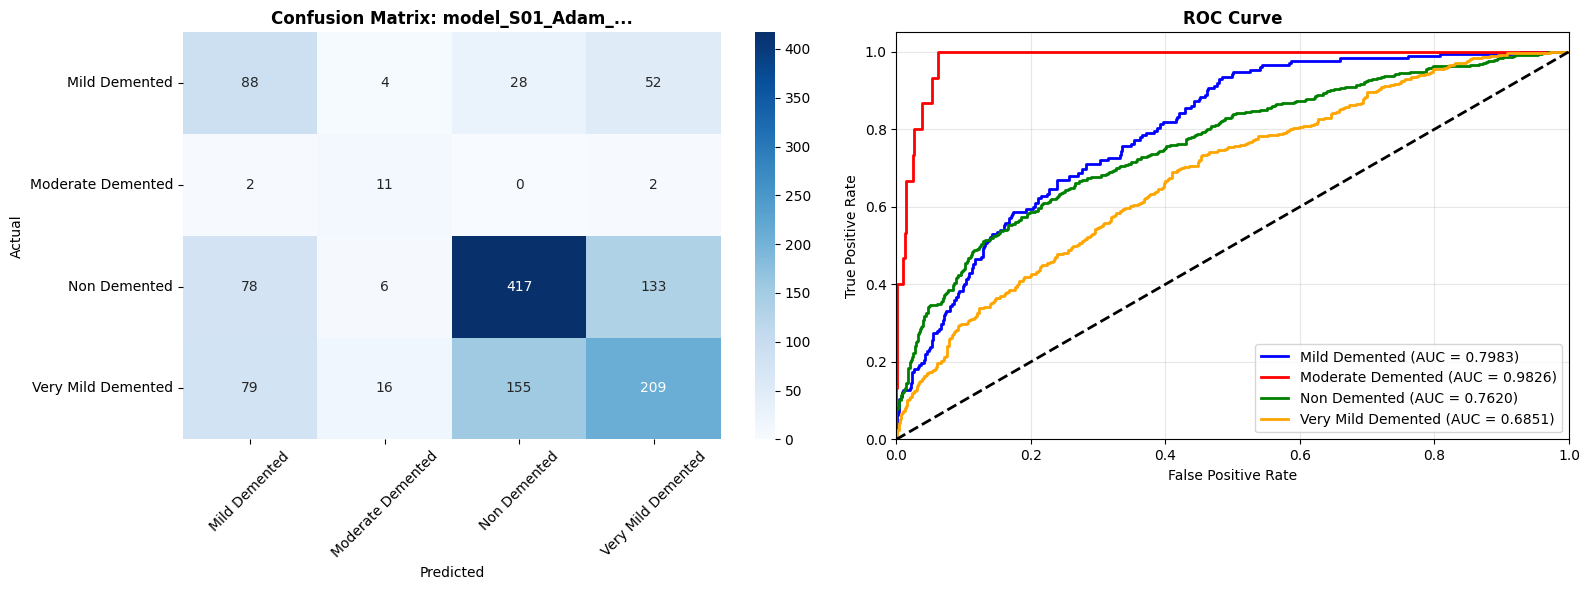


🚀 METODE: CLASS WEIGHT | MODEL: model_S02_Adam_CosineAnnealingLR.pth

[1] CLASSIFICATION REPORT
                    precision    recall  f1-score   support

     Mild Demented     0.3144    0.4826    0.3807       172
 Moderate Demented     0.3793    0.7333    0.5000        15
      Non Demented     0.7013    0.6703    0.6855       634
Very Mild Demented     0.5328    0.4423    0.4833       459

          accuracy                         0.5641      1280
         macro avg     0.4820    0.5821    0.5124      1280
      weighted avg     0.5851    0.5641    0.5699      1280


[2] CONFUSION MATRIX & ROC CURVE


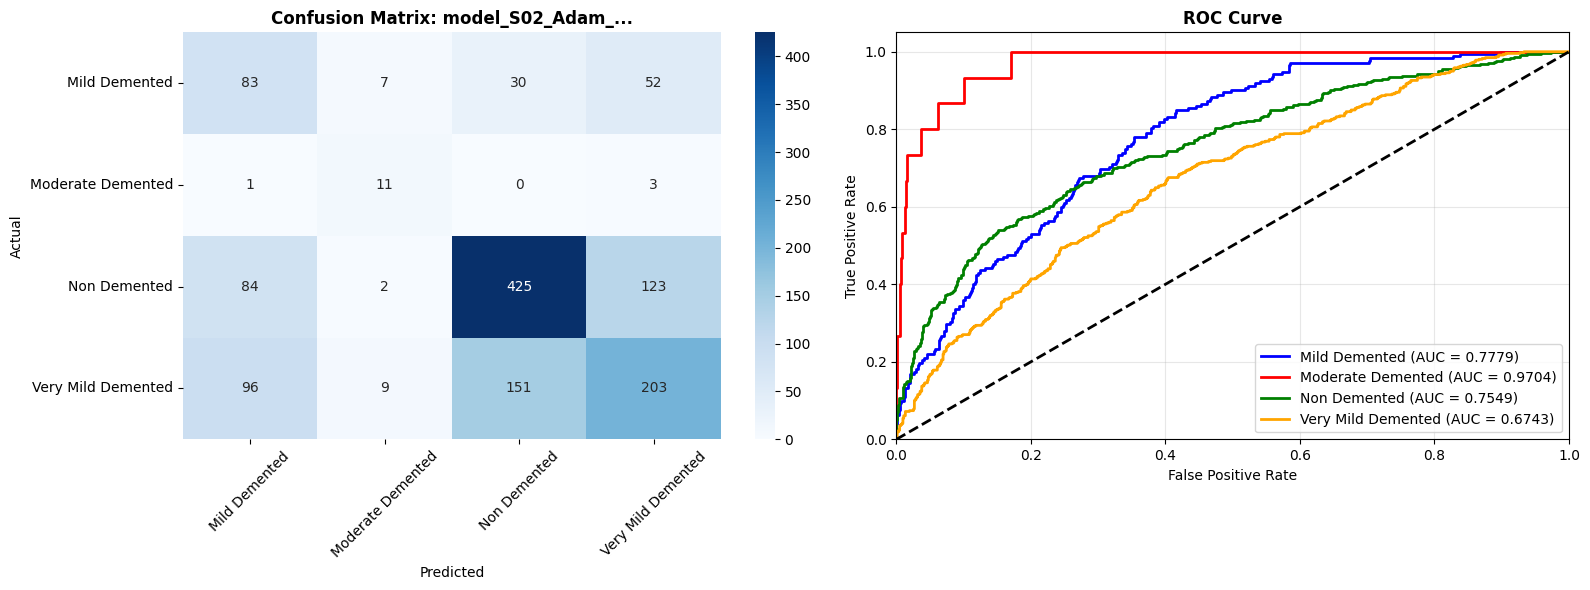


🚀 METODE: CLASS WEIGHT | MODEL: model_S03_AdamW_ReduceLROnPlateau.pth

[1] CLASSIFICATION REPORT
                    precision    recall  f1-score   support

     Mild Demented     0.3388    0.5988    0.4328       172
 Moderate Demented     0.2321    0.8667    0.3662        15
      Non Demented     0.6917    0.6546    0.6726       634
Very Mild Demented     0.5437    0.3791    0.4467       459

          accuracy                         0.5508      1280
         macro avg     0.4516    0.6248    0.4796      1280
      weighted avg     0.5858    0.5508    0.5558      1280


[2] CONFUSION MATRIX & ROC CURVE


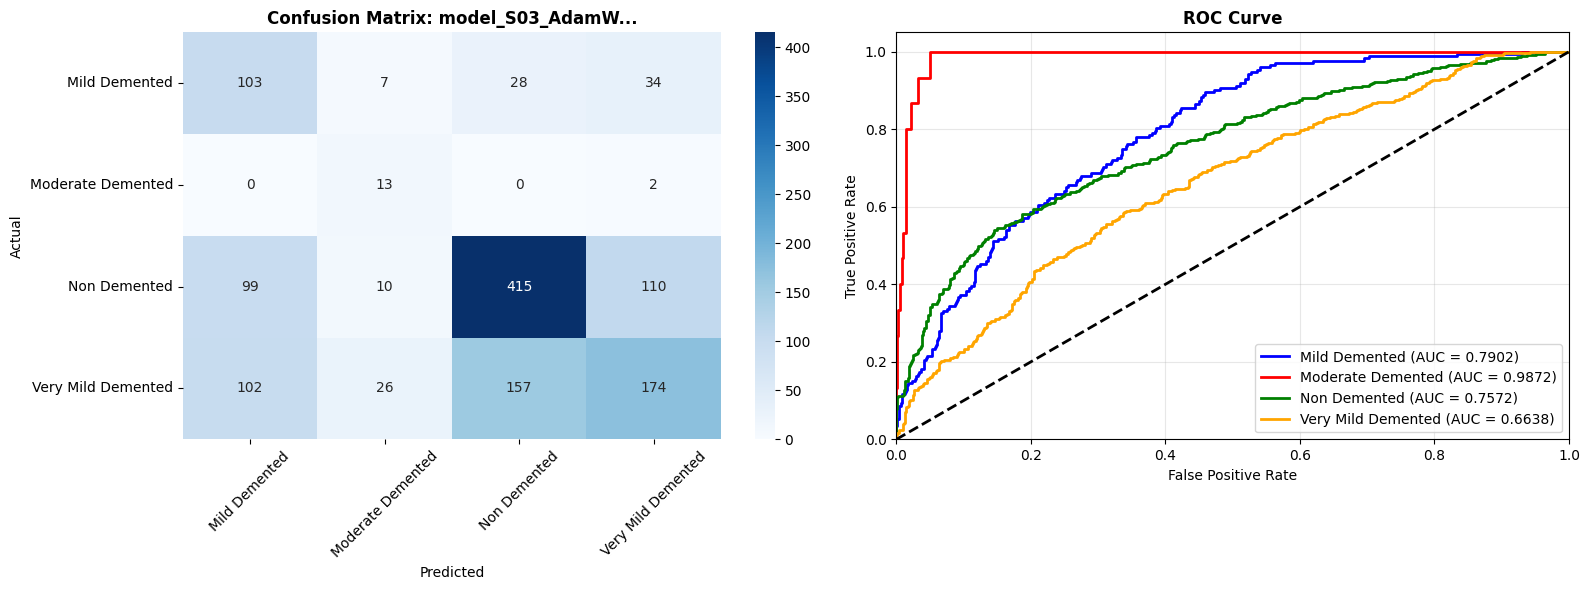


🚀 METODE: CLASS WEIGHT | MODEL: model_S04_AdamW_CosineAnnealingLR.pth

[1] CLASSIFICATION REPORT
                    precision    recall  f1-score   support

     Mild Demented     0.3139    0.5000    0.3857       172
 Moderate Demented     0.3000    0.6000    0.4000        15
      Non Demented     0.6924    0.6498    0.6705       634
Very Mild Demented     0.5197    0.4314    0.4714       459

          accuracy                         0.5508      1280
         macro avg     0.4565    0.5453    0.4819      1280
      weighted avg     0.5750    0.5508    0.5576      1280


[2] CONFUSION MATRIX & ROC CURVE


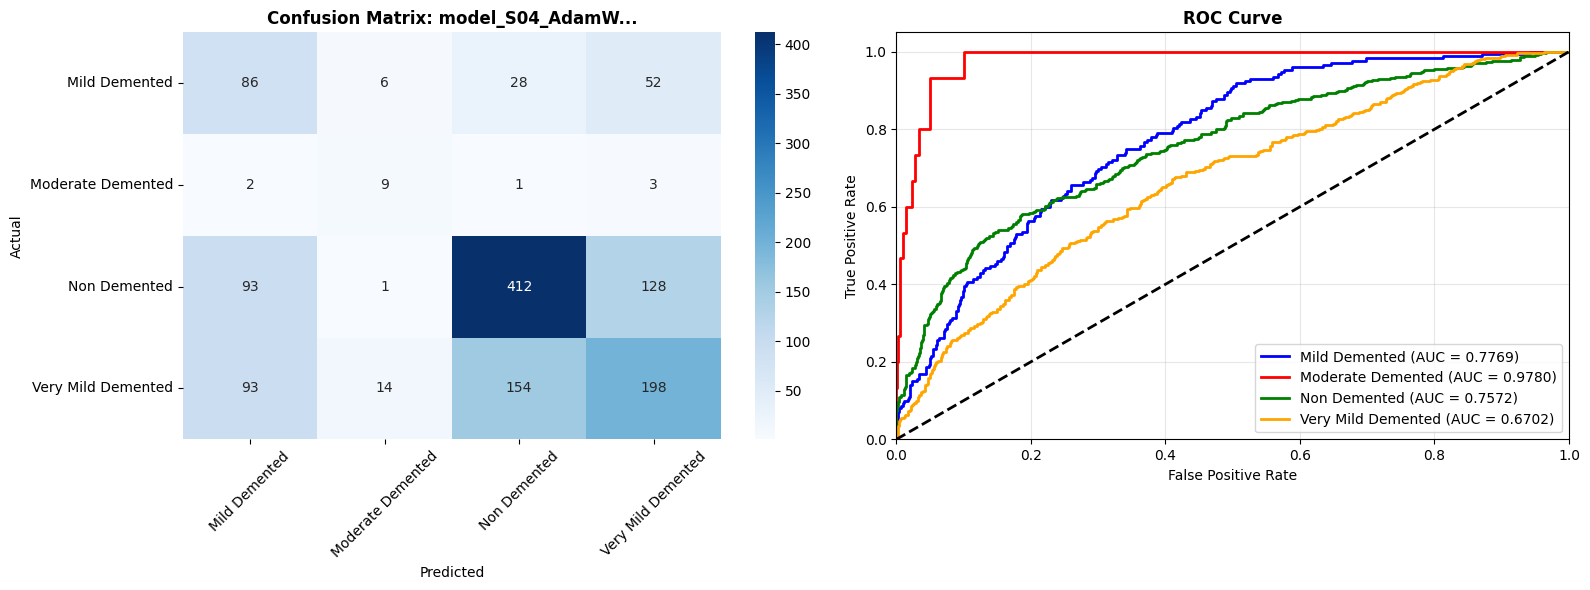


🚀 METODE: CLASS WEIGHT | MODEL: model_S05_SGD_ReduceLROnPlateau.pth

[1] CLASSIFICATION REPORT
                    precision    recall  f1-score   support

     Mild Demented     0.2973    0.4477    0.3573       172
 Moderate Demented     0.0000    0.0000    0.0000        15
      Non Demented     0.6397    0.7114    0.6736       634
Very Mild Demented     0.4810    0.3312    0.3923       459

          accuracy                         0.5312      1280
         macro avg     0.3545    0.3725    0.3558      1280
      weighted avg     0.5293    0.5312    0.5223      1280


[2] CONFUSION MATRIX & ROC CURVE


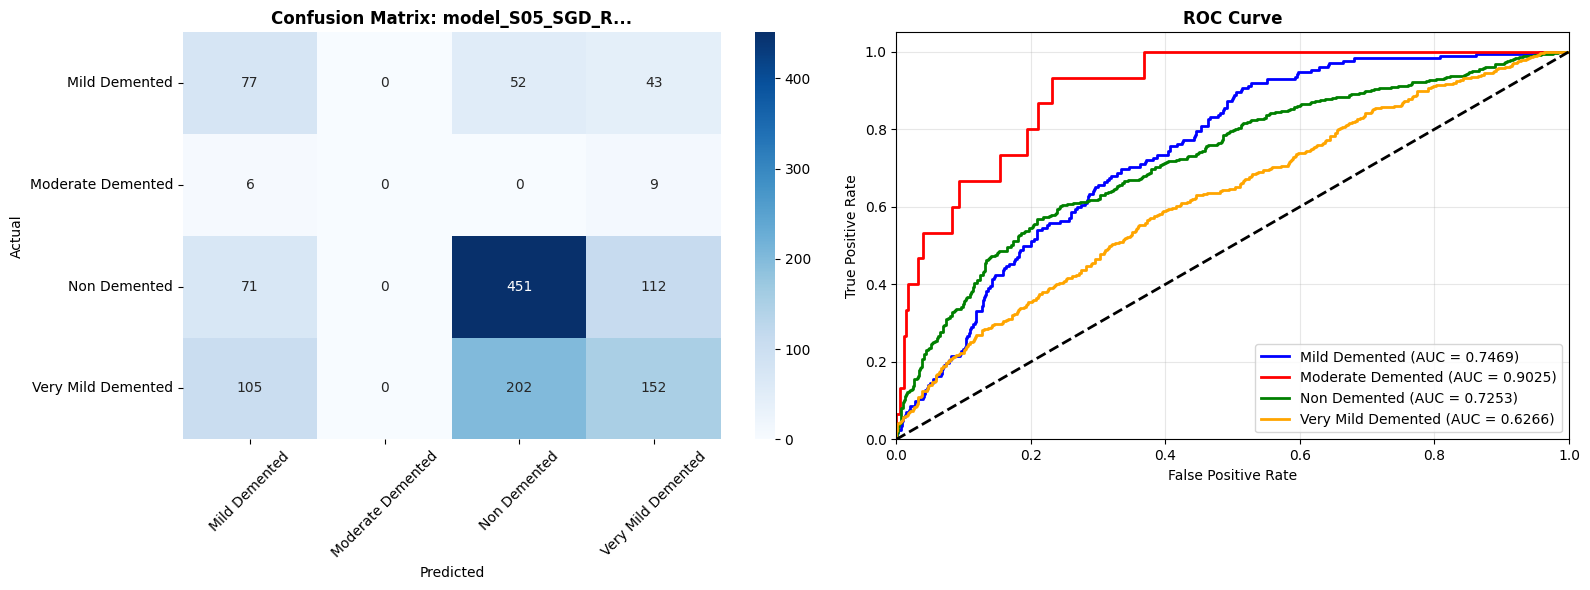


🚀 METODE: CLASS WEIGHT | MODEL: model_S06_SGD_CosineAnnealingLR.pth

[1] CLASSIFICATION REPORT
                    precision    recall  f1-score   support

     Mild Demented     0.3041    0.3023    0.3032       172
 Moderate Demented     0.0000    0.0000    0.0000        15
      Non Demented     0.6242    0.7334    0.6744       634
Very Mild Demented     0.4890    0.3878    0.4326       459

          accuracy                         0.5430      1280
         macro avg     0.3543    0.3559    0.3525      1280
      weighted avg     0.5254    0.5430    0.5299      1280


[2] CONFUSION MATRIX & ROC CURVE


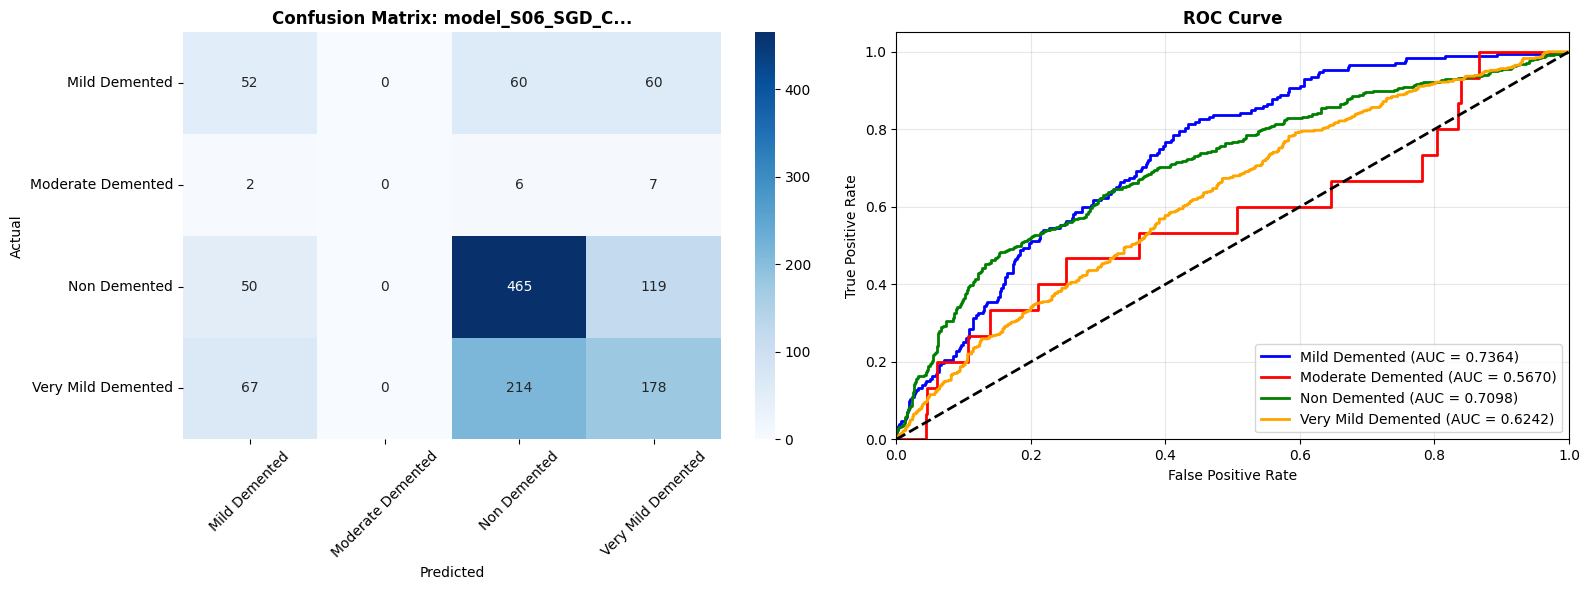


🚀 METODE: CLASS WEIGHT | MODEL: model_S07_Adam_ReduceLROnPlateau.pth

[1] CLASSIFICATION REPORT
                    precision    recall  f1-score   support

     Mild Demented     0.9382    0.9709    0.9543       172
 Moderate Demented     0.9375    1.0000    0.9677        15
      Non Demented     0.9852    0.9432    0.9637       634
Very Mild Demented     0.9353    0.9760    0.9552       459

          accuracy                         0.9594      1280
         macro avg     0.9490    0.9725    0.9602      1280
      weighted avg     0.9604    0.9594    0.9595      1280


[2] CONFUSION MATRIX & ROC CURVE


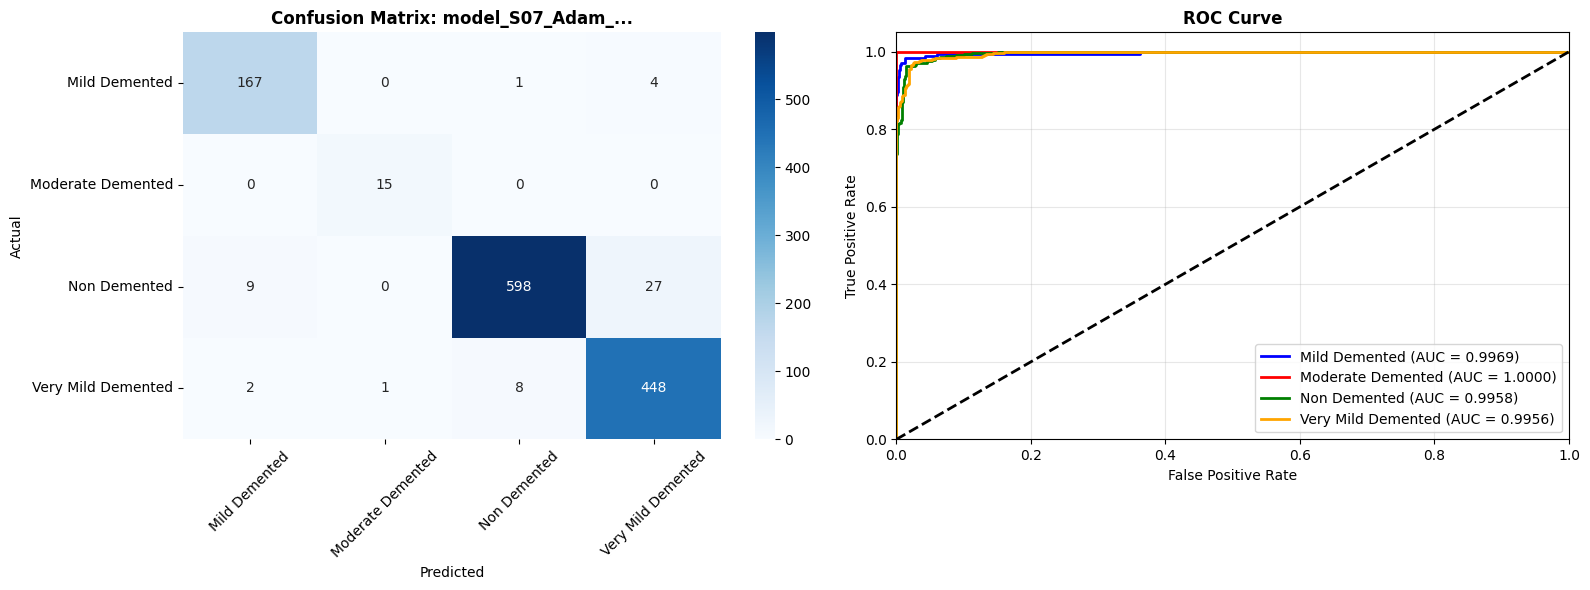


🚀 METODE: CLASS WEIGHT | MODEL: model_S08_Adam_CosineAnnealingLR.pth

[1] CLASSIFICATION REPORT
                    precision    recall  f1-score   support

     Mild Demented     0.9330    0.9709    0.9516       172
 Moderate Demented     1.0000    1.0000    1.0000        15
      Non Demented     0.9724    0.9464    0.9592       634
Very Mild Demented     0.9254    0.9455    0.9353       459

          accuracy                         0.9500      1280
         macro avg     0.9577    0.9657    0.9615      1280
      weighted avg     0.9506    0.9500    0.9501      1280


[2] CONFUSION MATRIX & ROC CURVE


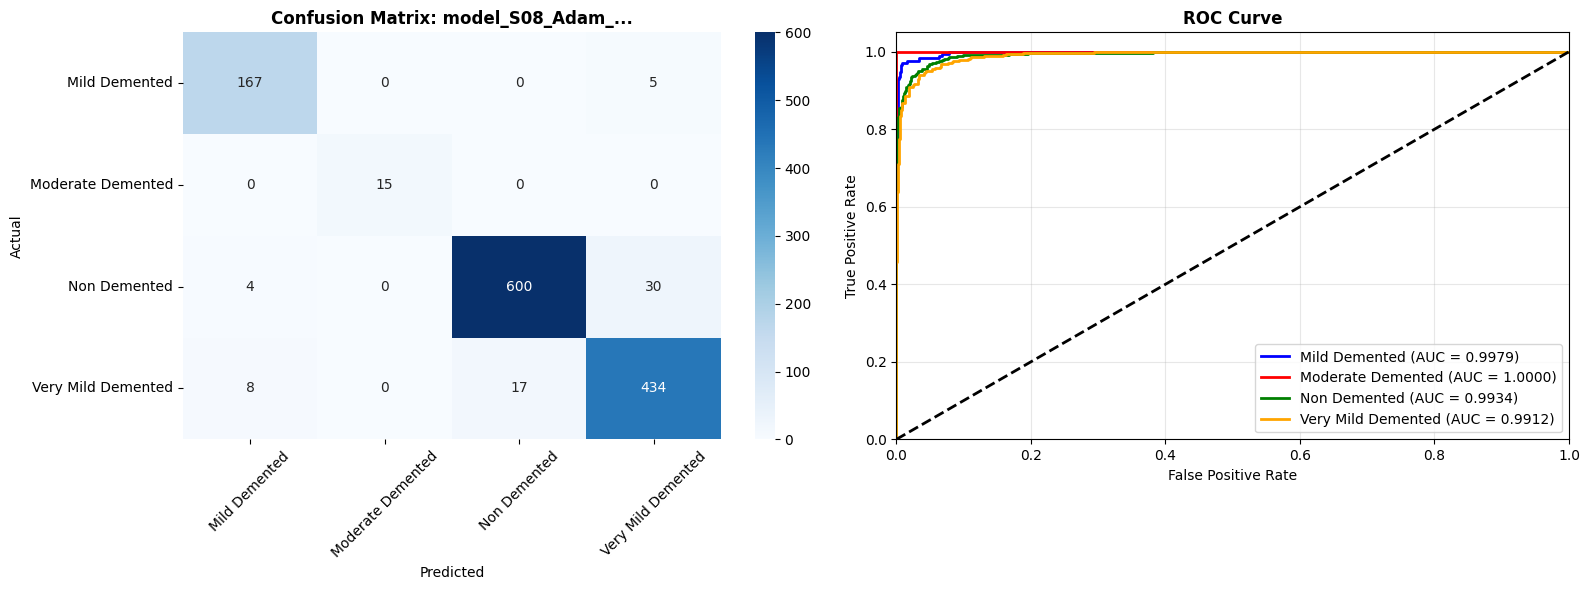


🚀 METODE: CLASS WEIGHT | MODEL: model_S09_AdamW_ReduceLROnPlateau.pth

[1] CLASSIFICATION REPORT
                    precision    recall  f1-score   support

     Mild Demented     0.9760    0.9477    0.9617       172
 Moderate Demented     1.0000    1.0000    1.0000        15
      Non Demented     0.9684    0.9653    0.9668       634
Very Mild Demented     0.9378    0.9521    0.9449       459

          accuracy                         0.9586      1280
         macro avg     0.9705    0.9663    0.9683      1280
      weighted avg     0.9588    0.9586    0.9586      1280


[2] CONFUSION MATRIX & ROC CURVE


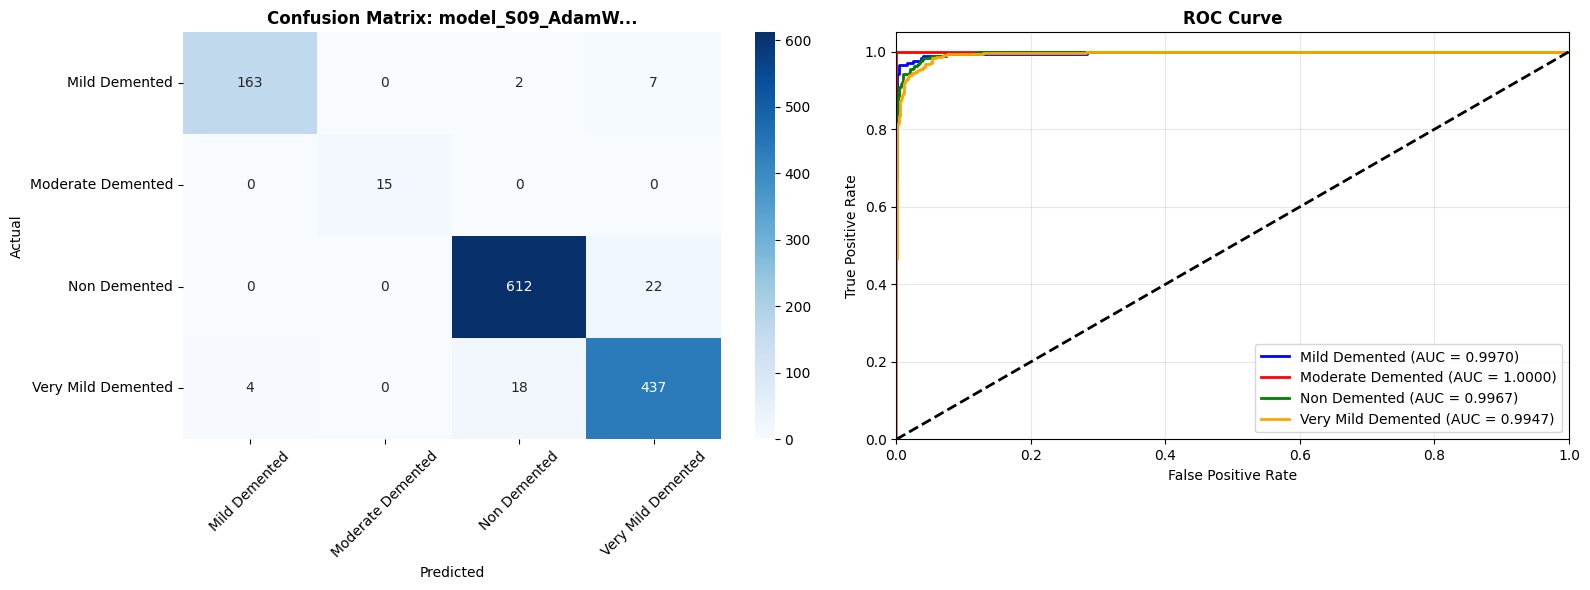


🚀 METODE: CLASS WEIGHT | MODEL: model_S10_AdamW_CosineAnnealingLR.pth

[1] CLASSIFICATION REPORT
                    precision    recall  f1-score   support

     Mild Demented     0.9425    0.9535    0.9480       172
 Moderate Demented     1.0000    1.0000    1.0000        15
      Non Demented     0.9586    0.9495    0.9540       634
Very Mild Demented     0.9287    0.9368    0.9328       459

          accuracy                         0.9461      1280
         macro avg     0.9575    0.9600    0.9587      1280
      weighted avg     0.9462    0.9461    0.9461      1280


[2] CONFUSION MATRIX & ROC CURVE


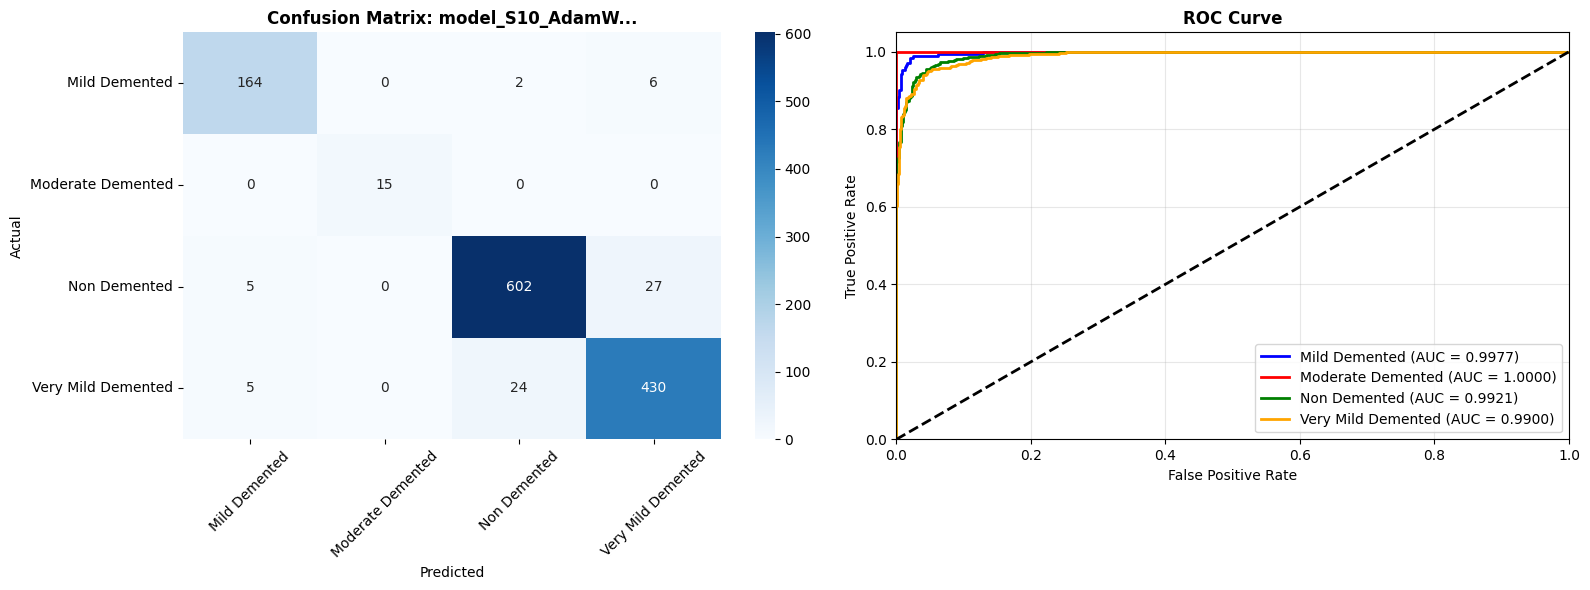


🚀 METODE: CLASS WEIGHT | MODEL: model_S11_SGD_ReduceLROnPlateau.pth

[1] CLASSIFICATION REPORT
                    precision    recall  f1-score   support

     Mild Demented     0.2931    0.6628    0.4064       172
 Moderate Demented     0.0000    0.0000    0.0000        15
      Non Demented     0.7143    0.6546    0.6831       634
Very Mild Demented     0.4628    0.3115    0.3724       459

          accuracy                         0.5250      1280
         macro avg     0.3675    0.4072    0.3655      1280
      weighted avg     0.5591    0.5250    0.5265      1280


[2] CONFUSION MATRIX & ROC CURVE


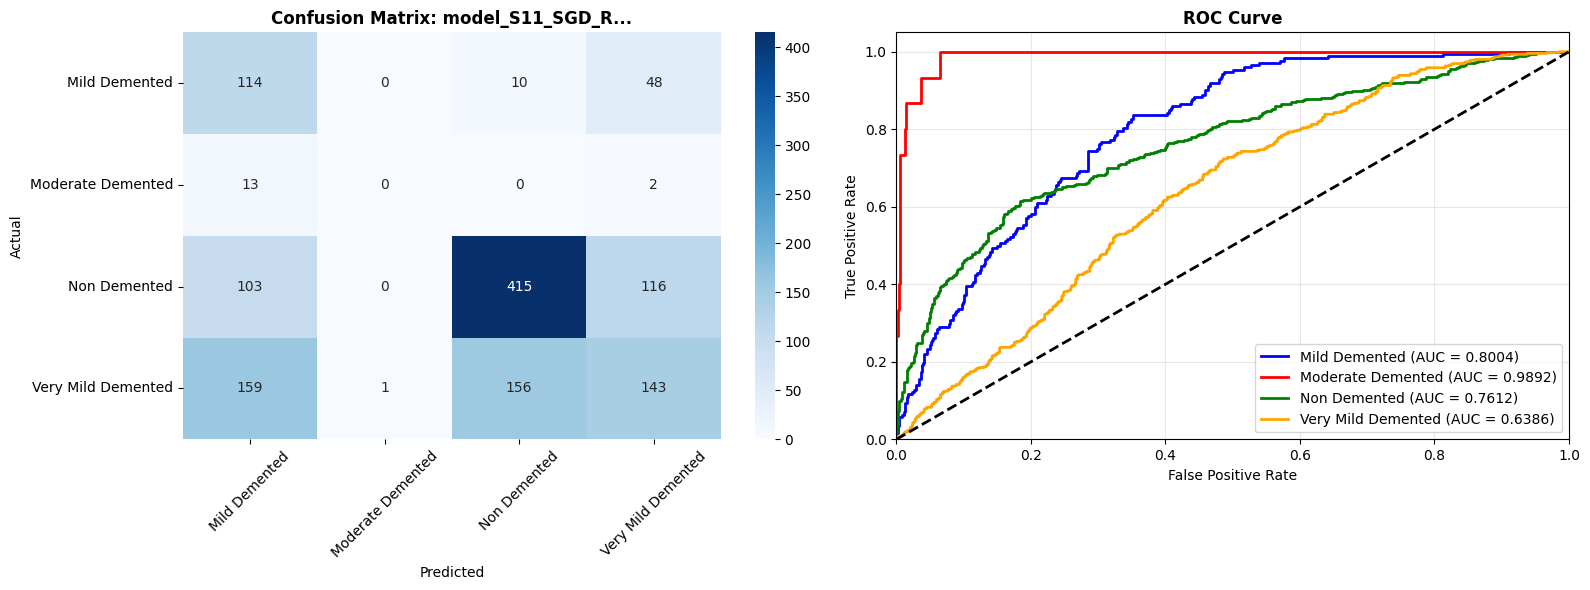


🚀 METODE: CLASS WEIGHT | MODEL: model_S12_SGD_CosineAnnealingLR.pth

[1] CLASSIFICATION REPORT
                    precision    recall  f1-score   support

     Mild Demented     0.2975    0.6105    0.4000       172
 Moderate Demented     0.0000    0.0000    0.0000        15
      Non Demented     0.6406    0.7508    0.6914       634
Very Mild Demented     0.5489    0.2200    0.3142       459

          accuracy                         0.5328      1280
         macro avg     0.3718    0.3953    0.3514      1280
      weighted avg     0.5541    0.5328    0.5088      1280


[2] CONFUSION MATRIX & ROC CURVE


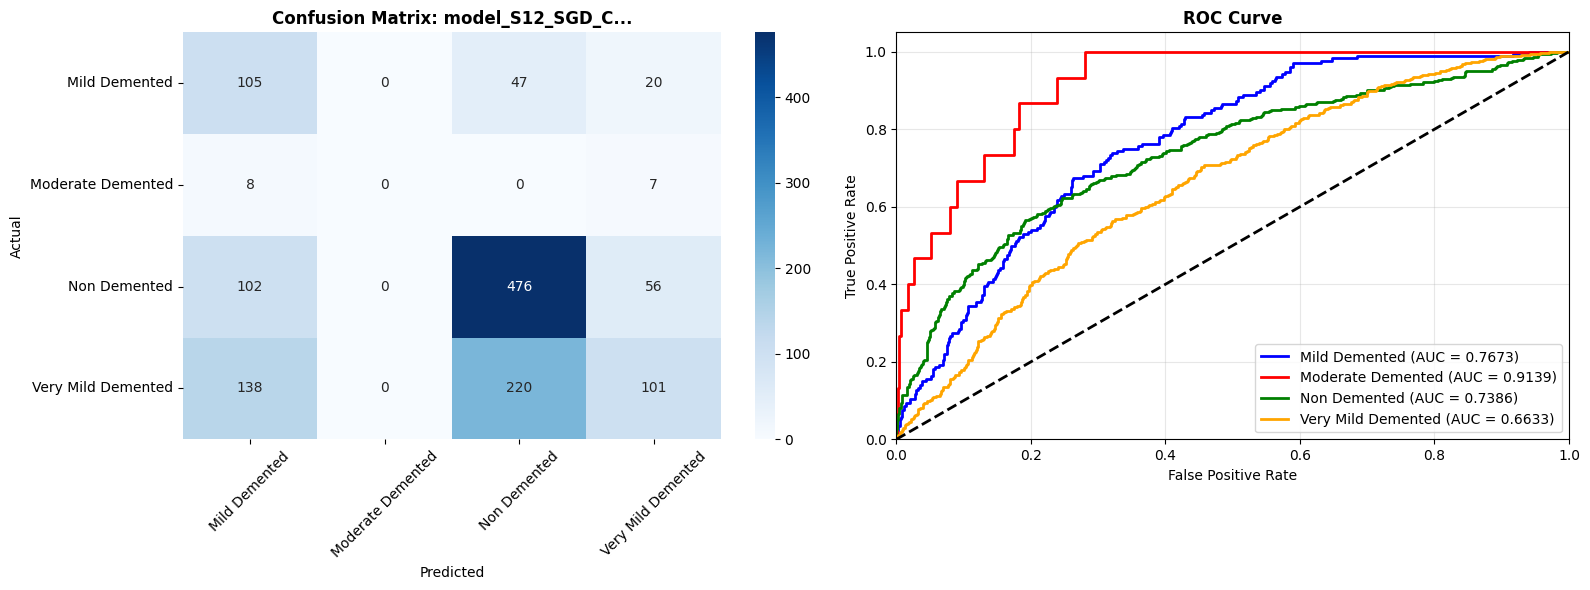


🚀 METODE: CLASS WEIGHT | MODEL: model_S13_Adam_ReduceLROnPlateau.pth

[1] CLASSIFICATION REPORT
                    precision    recall  f1-score   support

     Mild Demented     0.9882    0.9767    0.9825       172
 Moderate Demented     1.0000    1.0000    1.0000        15
      Non Demented     0.9890    0.9905    0.9898       634
Very Mild Demented     0.9848    0.9869    0.9859       459

          accuracy                         0.9875      1280
         macro avg     0.9905    0.9886    0.9895      1280
      weighted avg     0.9875    0.9875    0.9875      1280


[2] CONFUSION MATRIX & ROC CURVE


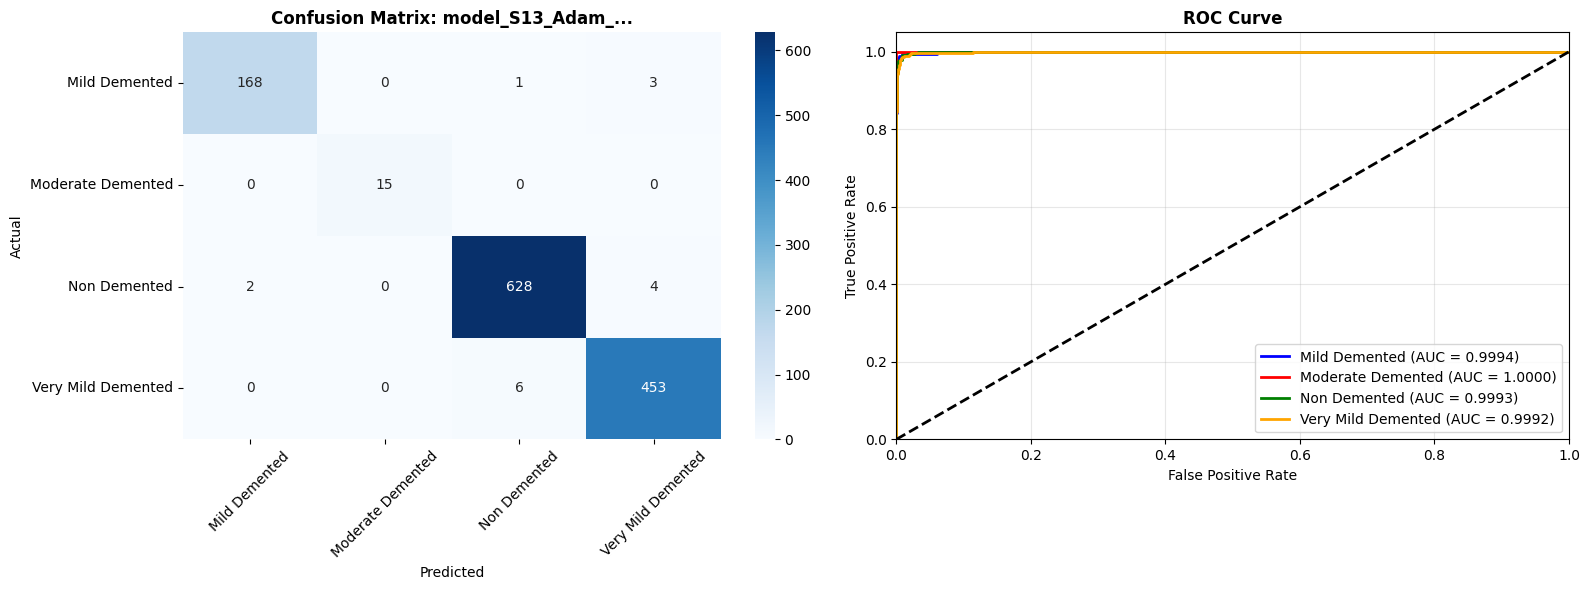


🚀 METODE: CLASS WEIGHT | MODEL: model_S14_Adam_CosineAnnealingLR.pth

[1] CLASSIFICATION REPORT
                    precision    recall  f1-score   support

     Mild Demented     0.9826    0.9826    0.9826       172
 Moderate Demented     1.0000    1.0000    1.0000        15
      Non Demented     0.9858    0.9842    0.9850       634
Very Mild Demented     0.9804    0.9826    0.9815       459

          accuracy                         0.9836      1280
         macro avg     0.9872    0.9873    0.9873      1280
      weighted avg     0.9836    0.9836    0.9836      1280


[2] CONFUSION MATRIX & ROC CURVE


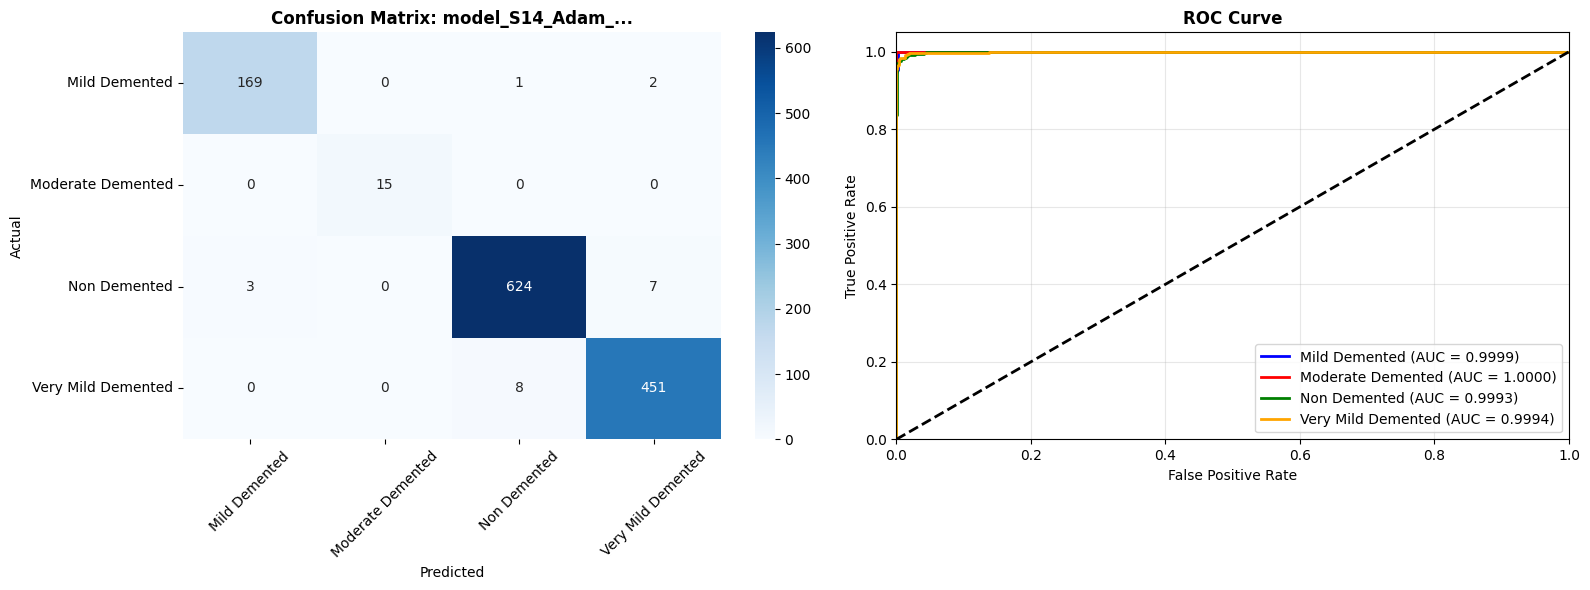


🚀 METODE: CLASS WEIGHT | MODEL: model_S15_AdamW_ReduceLROnPlateau.pth

[1] CLASSIFICATION REPORT
                    precision    recall  f1-score   support

     Mild Demented     0.9827    0.9884    0.9855       172
 Moderate Demented     1.0000    1.0000    1.0000        15
      Non Demented     0.9952    0.9890    0.9921       634
Very Mild Demented     0.9848    0.9913    0.9881       459

          accuracy                         0.9898      1280
         macro avg     0.9907    0.9922    0.9914      1280
      weighted avg     0.9899    0.9898    0.9899      1280


[2] CONFUSION MATRIX & ROC CURVE


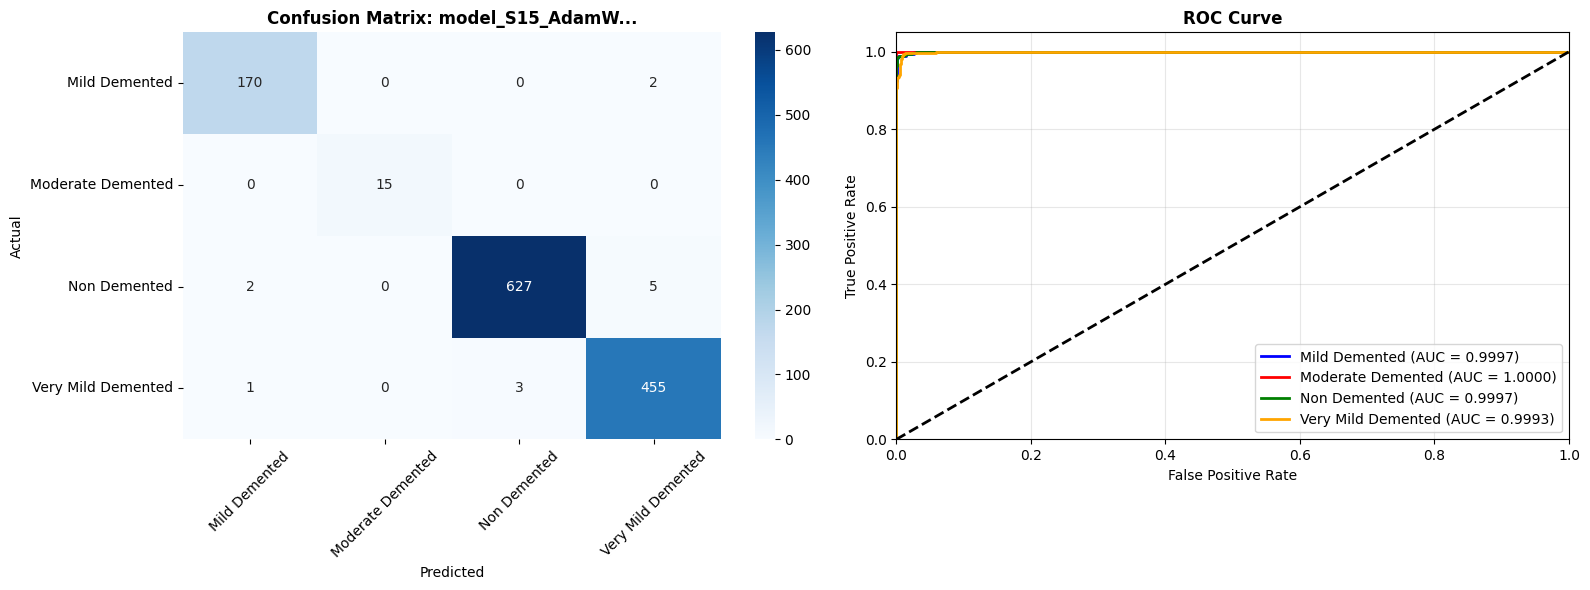


🚀 METODE: CLASS WEIGHT | MODEL: model_S16_AdamW_CosineAnnealingLR.pth

[1] CLASSIFICATION REPORT
                    precision    recall  f1-score   support

     Mild Demented     0.9770    0.9884    0.9827       172
 Moderate Demented     1.0000    1.0000    1.0000        15
      Non Demented     0.9937    0.9874    0.9905       634
Very Mild Demented     0.9848    0.9891    0.9870       459

          accuracy                         0.9883      1280
         macro avg     0.9889    0.9912    0.9900      1280
      weighted avg     0.9883    0.9883    0.9883      1280


[2] CONFUSION MATRIX & ROC CURVE


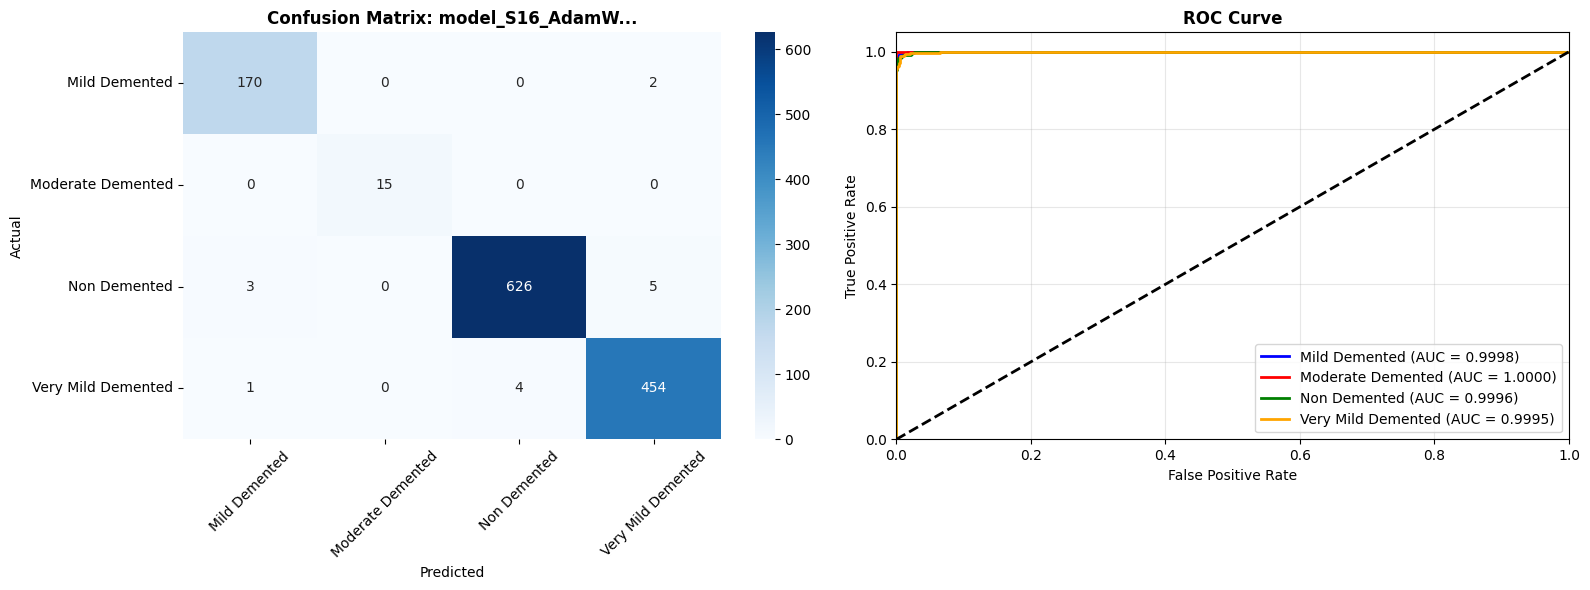


🚀 METODE: CLASS WEIGHT | MODEL: model_S17_SGD_ReduceLROnPlateau.pth

[1] CLASSIFICATION REPORT
                    precision    recall  f1-score   support

     Mild Demented     0.3369    0.7267    0.4604       172
 Moderate Demented     0.8000    0.5333    0.6400        15
      Non Demented     0.7413    0.6735    0.7058       634
Very Mild Demented     0.5356    0.3769    0.4425       459

          accuracy                         0.5727      1280
         macro avg     0.6035    0.5776    0.5622      1280
      weighted avg     0.6139    0.5727    0.5776      1280


[2] CONFUSION MATRIX & ROC CURVE


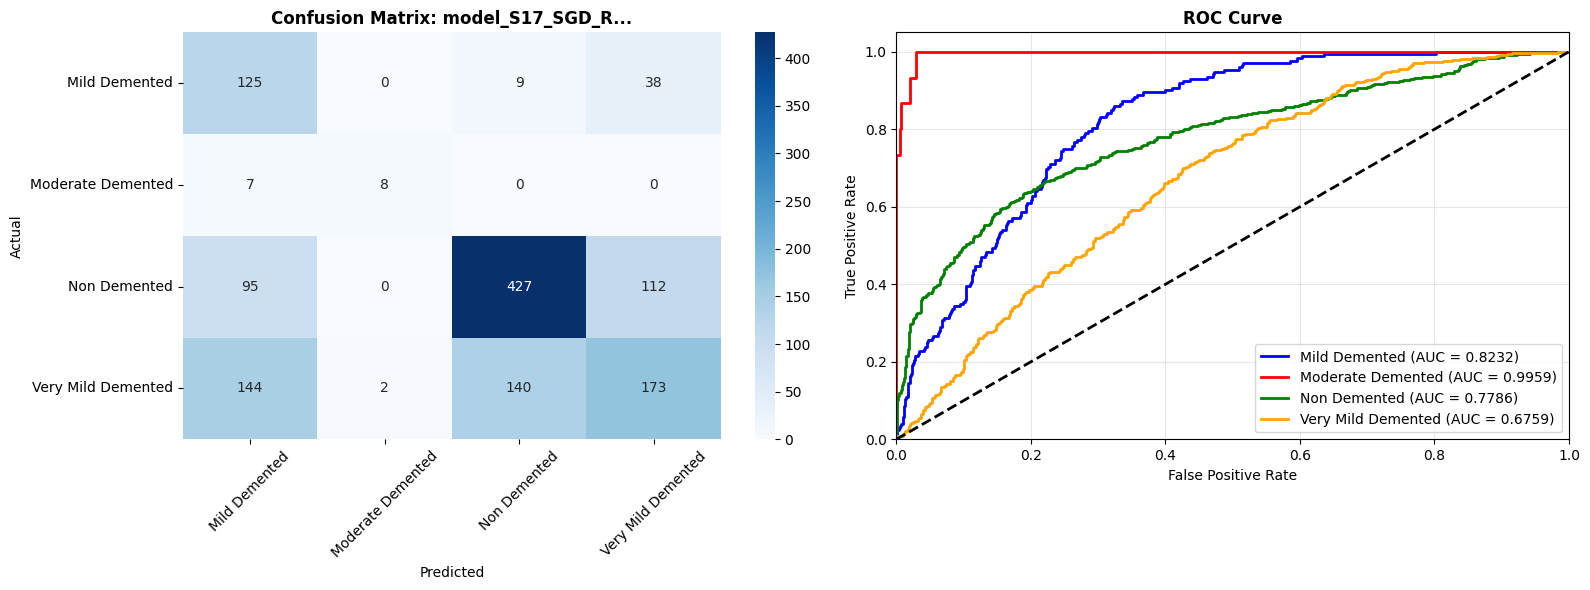


🚀 METODE: CLASS WEIGHT | MODEL: model_S18_SGD_CosineAnnealingLR.pth

[1] CLASSIFICATION REPORT
                    precision    recall  f1-score   support

     Mild Demented     0.2854    0.6570    0.3979       172
 Moderate Demented     0.0000    0.0000    0.0000        15
      Non Demented     0.6785    0.6924    0.6854       634
Very Mild Demented     0.4979    0.2571    0.3391       459

          accuracy                         0.5234      1280
         macro avg     0.3654    0.4016    0.3556      1280
      weighted avg     0.5530    0.5234    0.5145      1280


[2] CONFUSION MATRIX & ROC CURVE


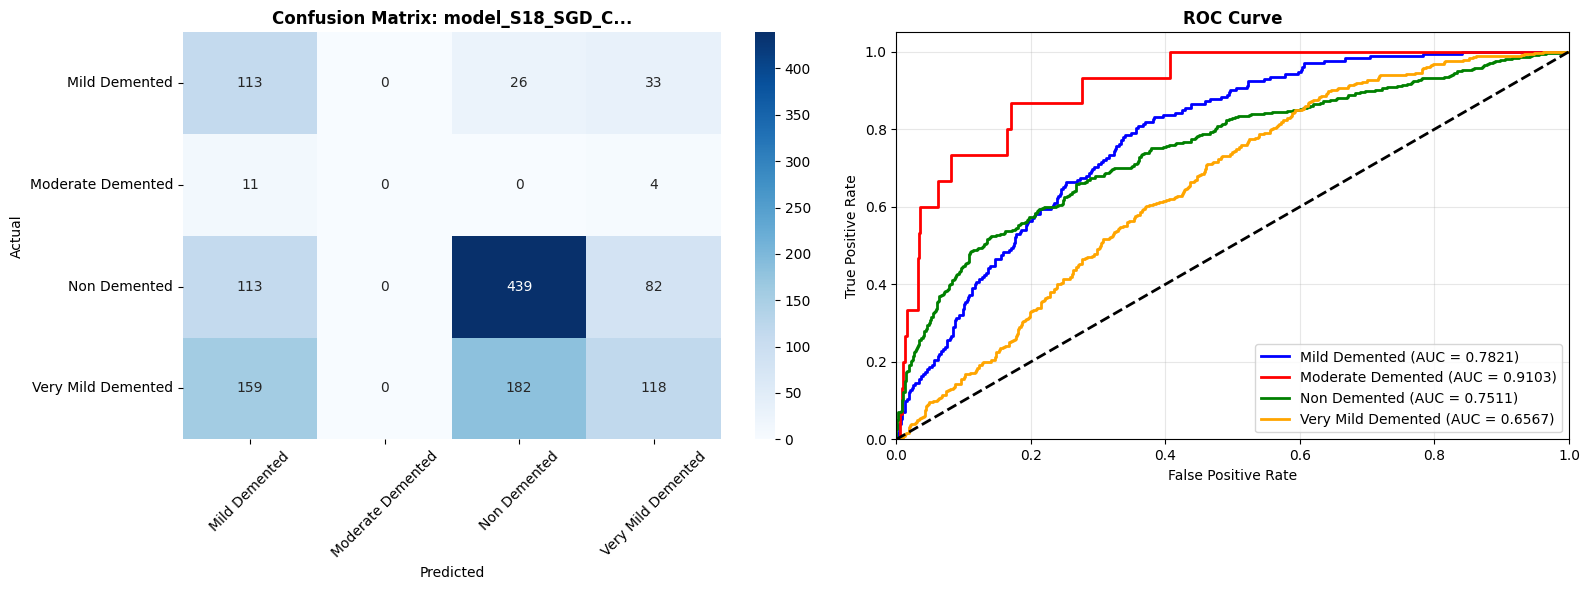


🚀 METODE: SAMPLER | MODEL: model_S01_Adam_ReduceLROnPlateau.pth

[1] CLASSIFICATION REPORT
                    precision    recall  f1-score   support

     Mild Demented     0.3565    0.4477    0.3969       172
 Moderate Demented     0.2727    1.0000    0.4286        15
      Non Demented     0.6931    0.6767    0.6848       634
Very Mild Demented     0.5103    0.4336    0.4688       459

          accuracy                         0.5625      1280
         macro avg     0.4581    0.6395    0.4948      1280
      weighted avg     0.5774    0.5625    0.5656      1280


[2] CONFUSION MATRIX & ROC CURVE


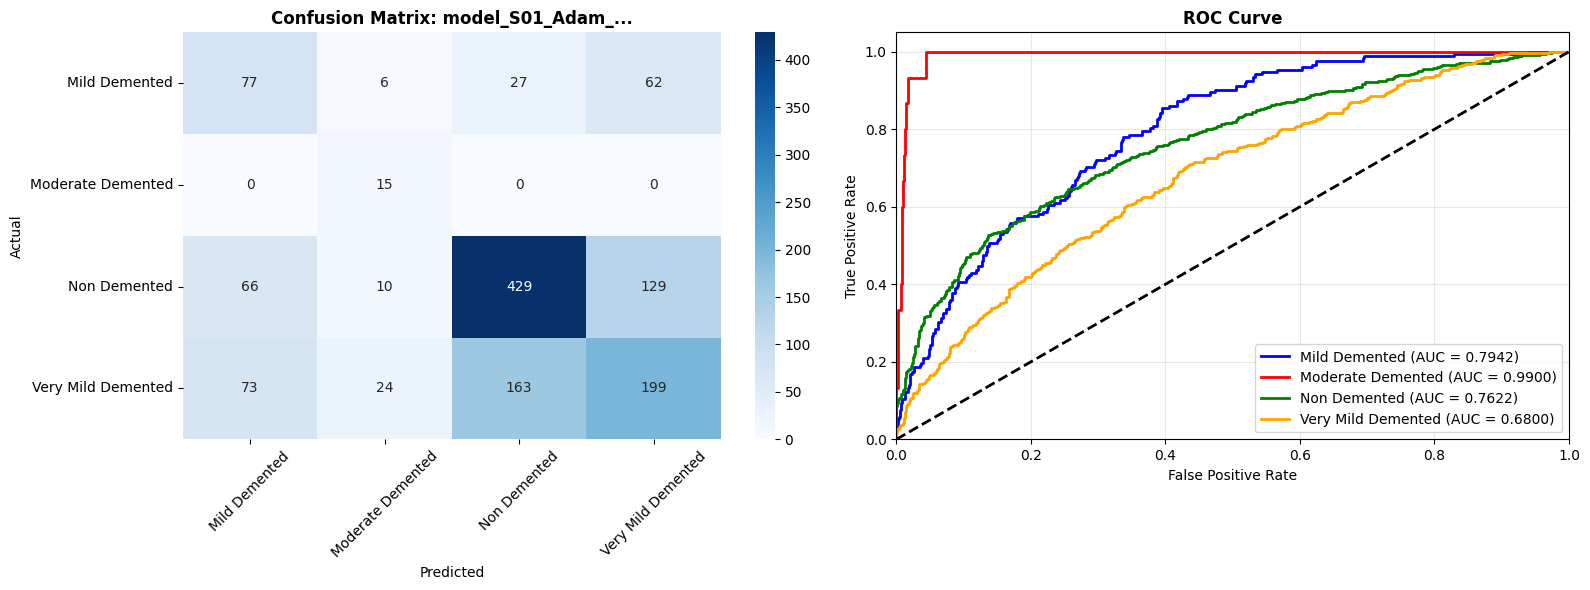


🚀 METODE: SAMPLER | MODEL: model_S02_Adam_CosineAnnealingLR.pth

[1] CLASSIFICATION REPORT
                    precision    recall  f1-score   support

     Mild Demented     0.3385    0.5116    0.4074       172
 Moderate Demented     0.1864    0.7333    0.2973        15
      Non Demented     0.6959    0.6498    0.6721       634
Very Mild Demented     0.5041    0.4052    0.4493       459

          accuracy                         0.5445      1280
         macro avg     0.4312    0.5750    0.4565      1280
      weighted avg     0.5731    0.5445    0.5522      1280


[2] CONFUSION MATRIX & ROC CURVE


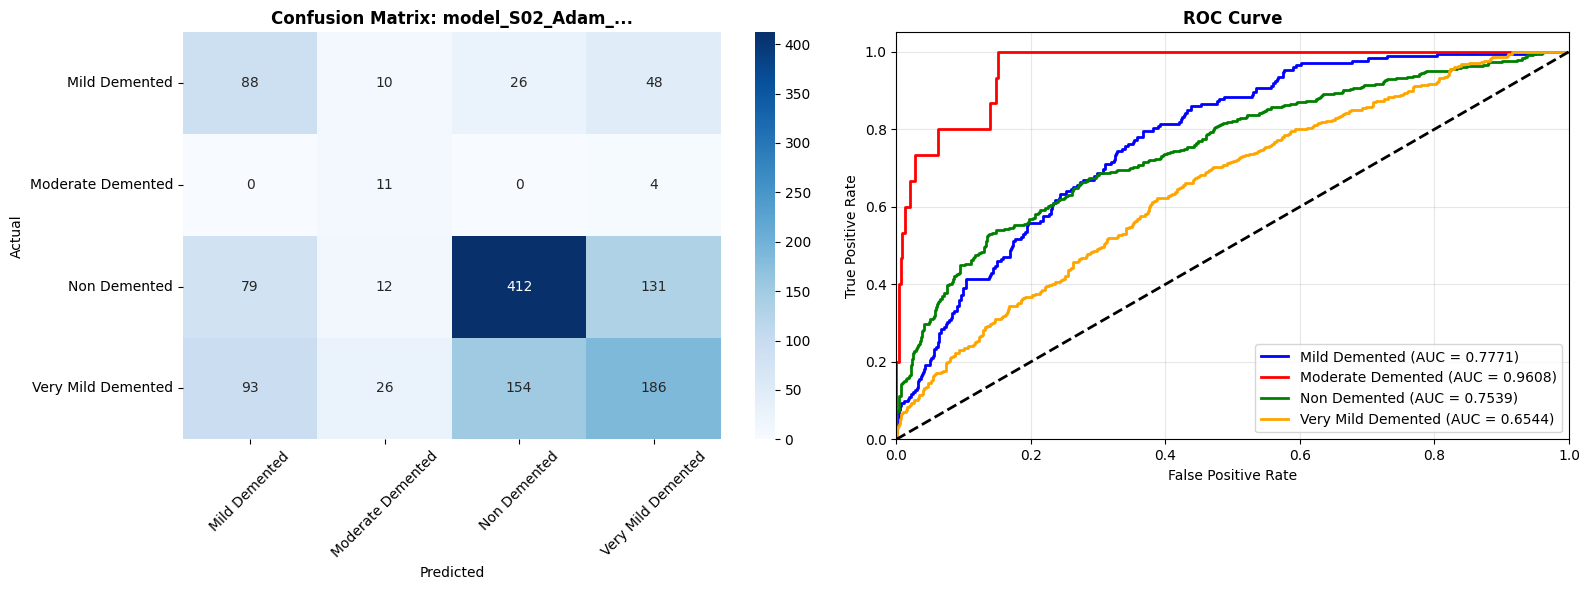


🚀 METODE: SAMPLER | MODEL: model_S03_AdamW_ReduceLROnPlateau.pth

[1] CLASSIFICATION REPORT
                    precision    recall  f1-score   support

     Mild Demented     0.3405    0.4593    0.3911       172
 Moderate Demented     0.2895    0.7333    0.4151        15
      Non Demented     0.7138    0.6215    0.6644       634
Very Mild Demented     0.4891    0.4880    0.4885       459

          accuracy                         0.5531      1280
         macro avg     0.4582    0.5755    0.4898      1280
      weighted avg     0.5781    0.5531    0.5617      1280


[2] CONFUSION MATRIX & ROC CURVE


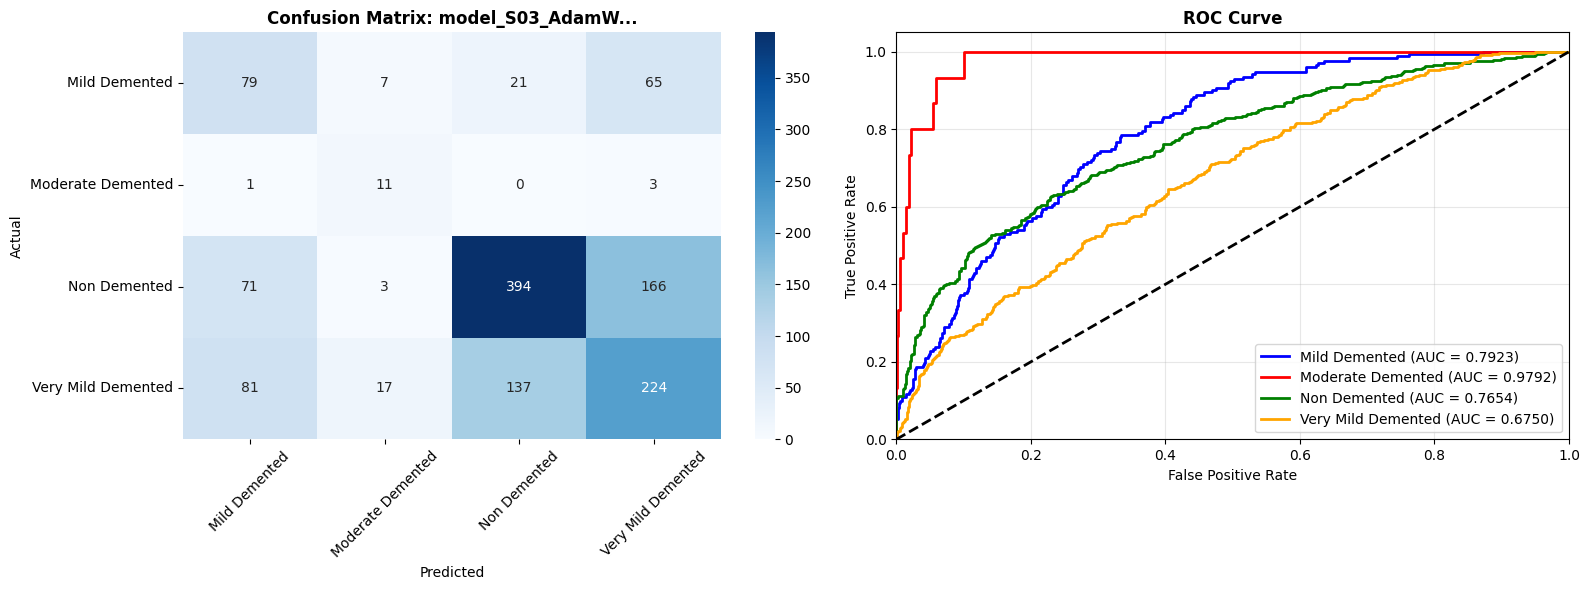


🚀 METODE: SAMPLER | MODEL: model_S04_AdamW_CosineAnnealingLR.pth

[1] CLASSIFICATION REPORT
                    precision    recall  f1-score   support

     Mild Demented     0.3496    0.5407    0.4247       172
 Moderate Demented     0.2895    0.7333    0.4151        15
      Non Demented     0.6915    0.6893    0.6904       634
Very Mild Demented     0.5552    0.4161    0.4757       459

          accuracy                         0.5719      1280
         macro avg     0.4714    0.5949    0.5015      1280
      weighted avg     0.5920    0.5719    0.5745      1280


[2] CONFUSION MATRIX & ROC CURVE


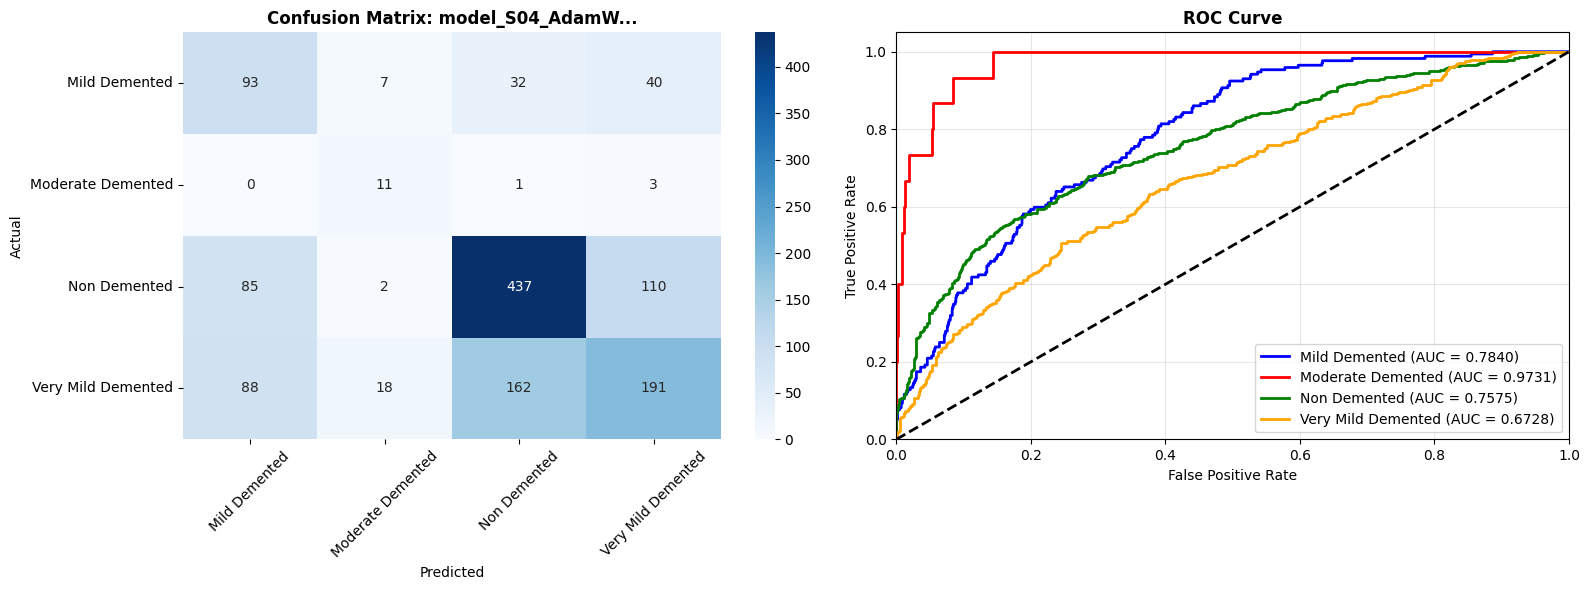


🚀 METODE: SAMPLER | MODEL: model_S05_SGD_ReduceLROnPlateau.pth

[1] CLASSIFICATION REPORT
                    precision    recall  f1-score   support

     Mild Demented     0.3049    0.4360    0.3589       172
 Moderate Demented     0.0000    0.0000    0.0000        15
      Non Demented     0.6134    0.7808    0.6870       634
Very Mild Demented     0.5022    0.2484    0.3324       459

          accuracy                         0.5344      1280
         macro avg     0.3551    0.3663    0.3446      1280
      weighted avg     0.5249    0.5344    0.5077      1280


[2] CONFUSION MATRIX & ROC CURVE


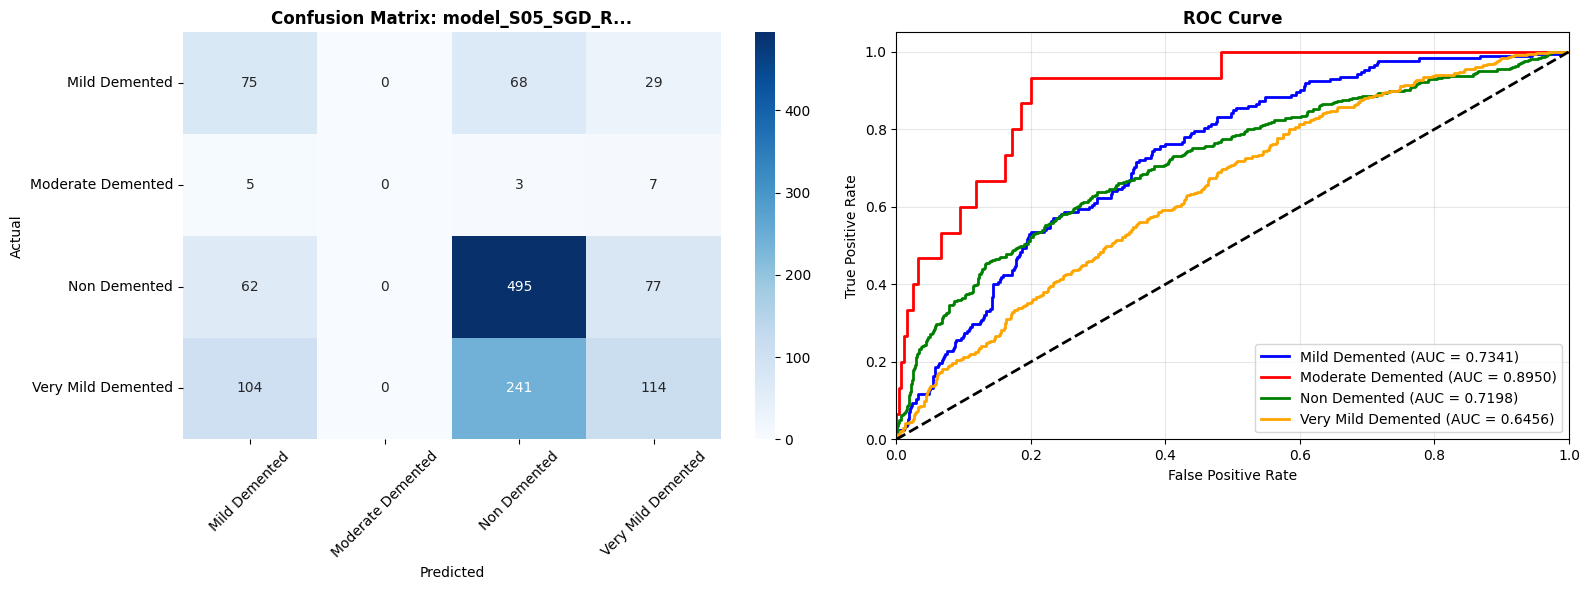


🚀 METODE: SAMPLER | MODEL: model_S06_SGD_CosineAnnealingLR.pth

[1] CLASSIFICATION REPORT
                    precision    recall  f1-score   support

     Mild Demented     0.2767    0.4070    0.3294       172
 Moderate Demented     0.0000    0.0000    0.0000        15
      Non Demented     0.5921    0.8013    0.6810       634
Very Mild Demented     0.5148    0.1895    0.2771       459

          accuracy                         0.5195      1280
         macro avg     0.3459    0.3494    0.3219      1280
      weighted avg     0.5150    0.5195    0.4809      1280


[2] CONFUSION MATRIX & ROC CURVE


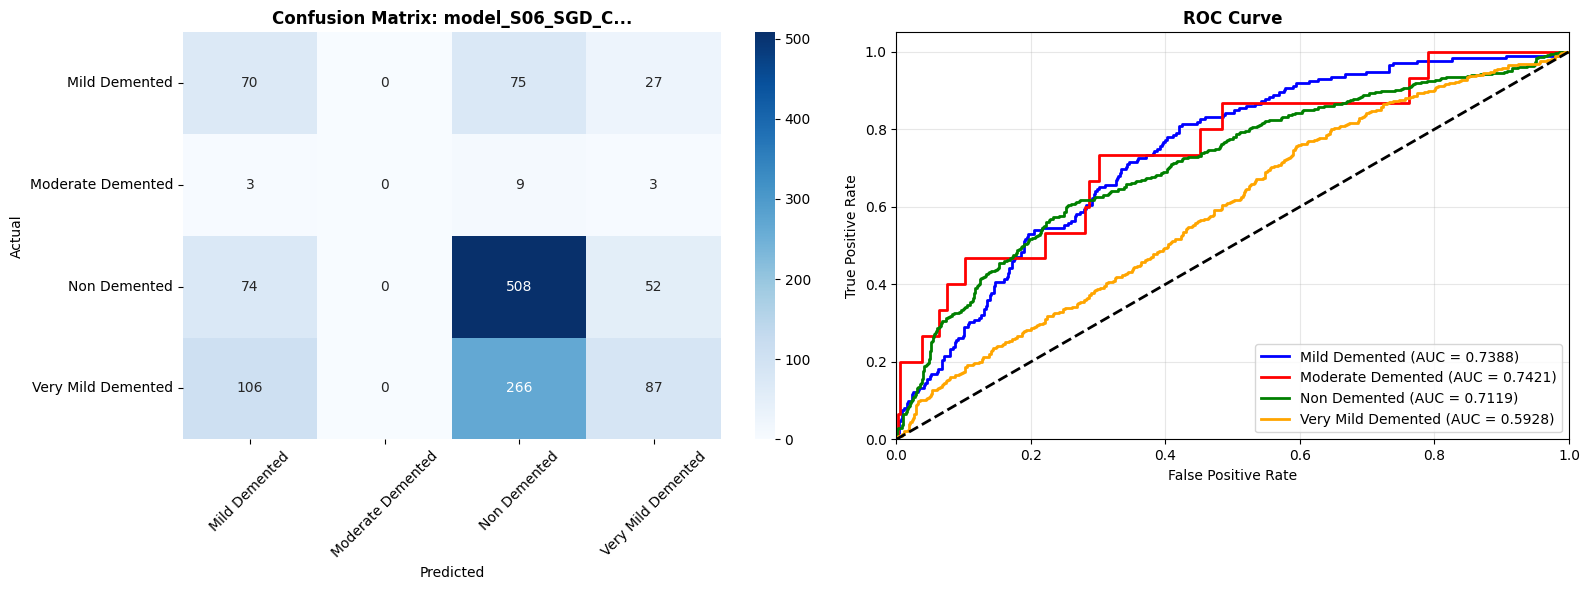


🚀 METODE: SAMPLER | MODEL: model_S07_Adam_ReduceLROnPlateau.pth

[1] CLASSIFICATION REPORT
                    precision    recall  f1-score   support

     Mild Demented     0.9527    0.9360    0.9443       172
 Moderate Demented     1.0000    1.0000    1.0000        15
      Non Demented     0.9822    0.9574    0.9696       634
Very Mild Demented     0.9351    0.9739    0.9541       459

          accuracy                         0.9609      1280
         macro avg     0.9675    0.9668    0.9670      1280
      weighted avg     0.9616    0.9609    0.9610      1280


[2] CONFUSION MATRIX & ROC CURVE


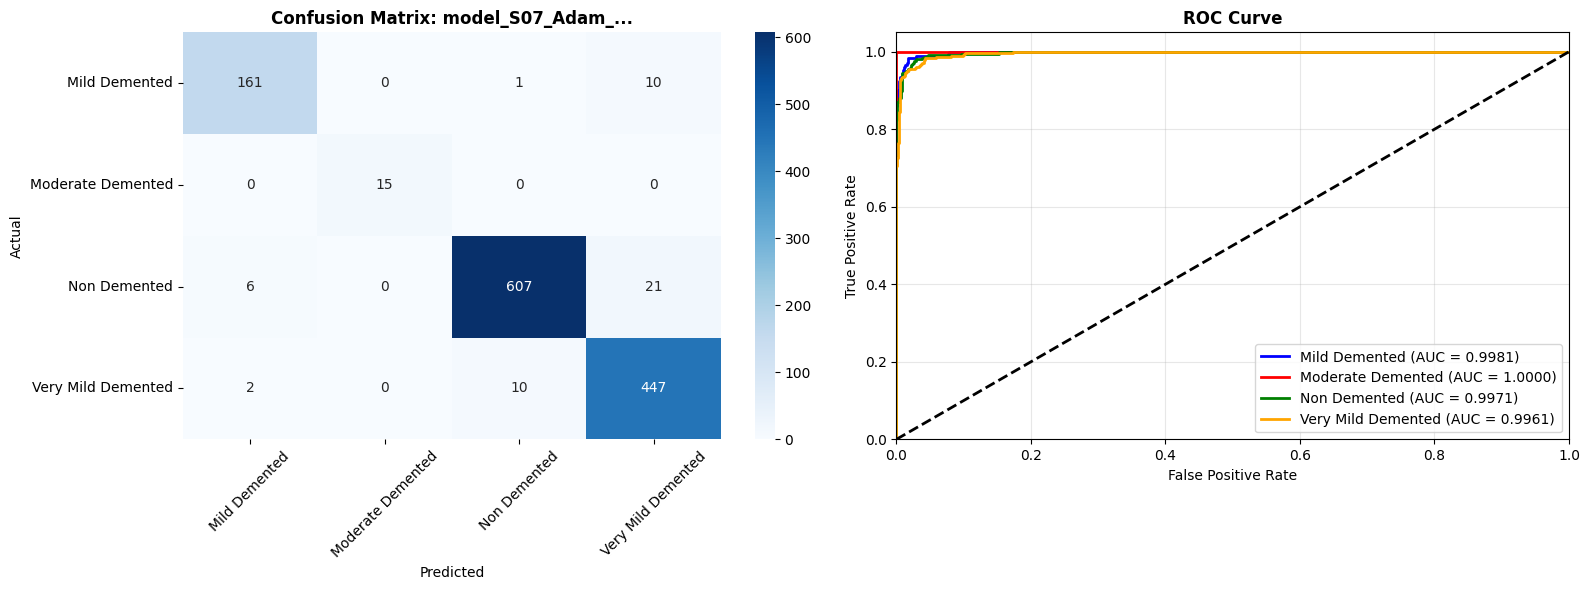


🚀 METODE: SAMPLER | MODEL: model_S08_Adam_CosineAnnealingLR.pth

[1] CLASSIFICATION REPORT
                    precision    recall  f1-score   support

     Mild Demented     0.8836    0.9709    0.9252       172
 Moderate Demented     1.0000    1.0000    1.0000        15
      Non Demented     0.9733    0.9211    0.9465       634
Very Mild Demented     0.9118    0.9455    0.9283       459

          accuracy                         0.9375      1280
         macro avg     0.9422    0.9594    0.9500      1280
      weighted avg     0.9395    0.9375    0.9378      1280


[2] CONFUSION MATRIX & ROC CURVE


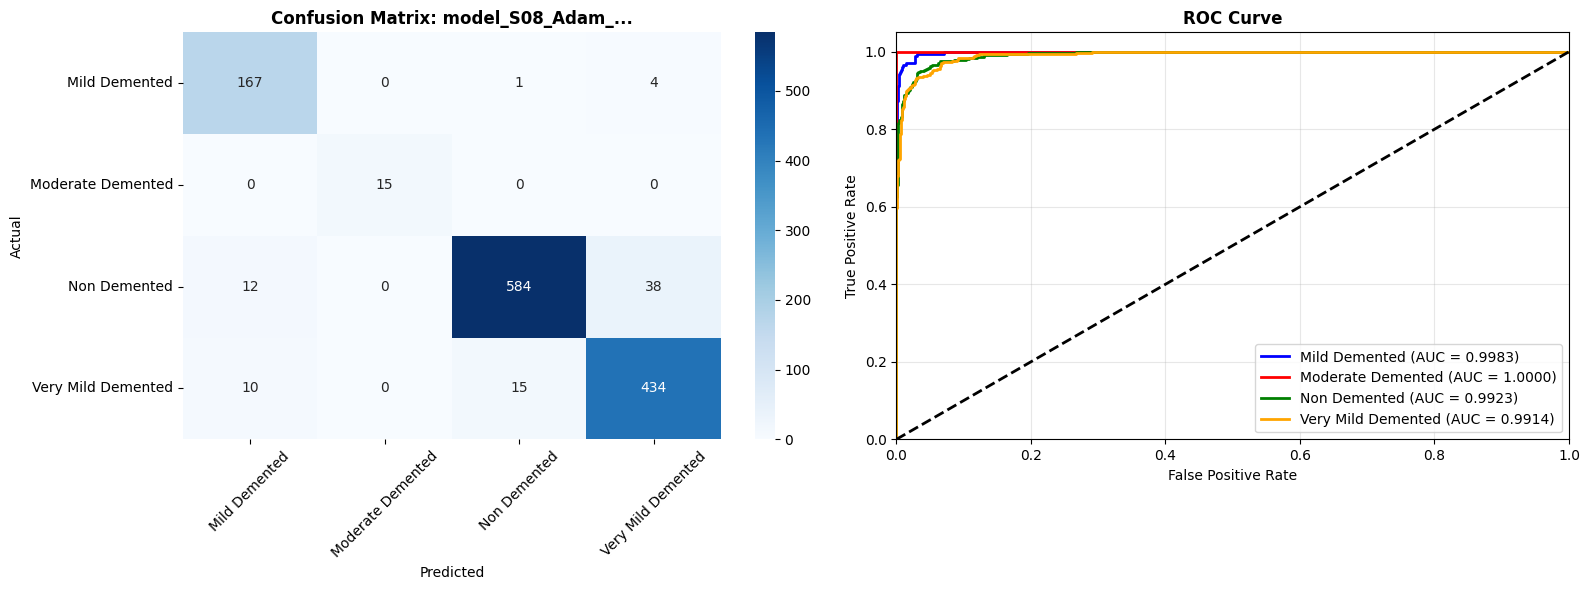


🚀 METODE: SAMPLER | MODEL: model_S09_AdamW_ReduceLROnPlateau.pth

[1] CLASSIFICATION REPORT
                    precision    recall  f1-score   support

     Mild Demented     0.9770    0.9884    0.9827       172
 Moderate Demented     1.0000    1.0000    1.0000        15
      Non Demented     0.9950    0.9338    0.9634       634
Very Mild Demented     0.9173    0.9913    0.9529       459

          accuracy                         0.9625      1280
         macro avg     0.9723    0.9784    0.9747      1280
      weighted avg     0.9648    0.9625    0.9626      1280


[2] CONFUSION MATRIX & ROC CURVE


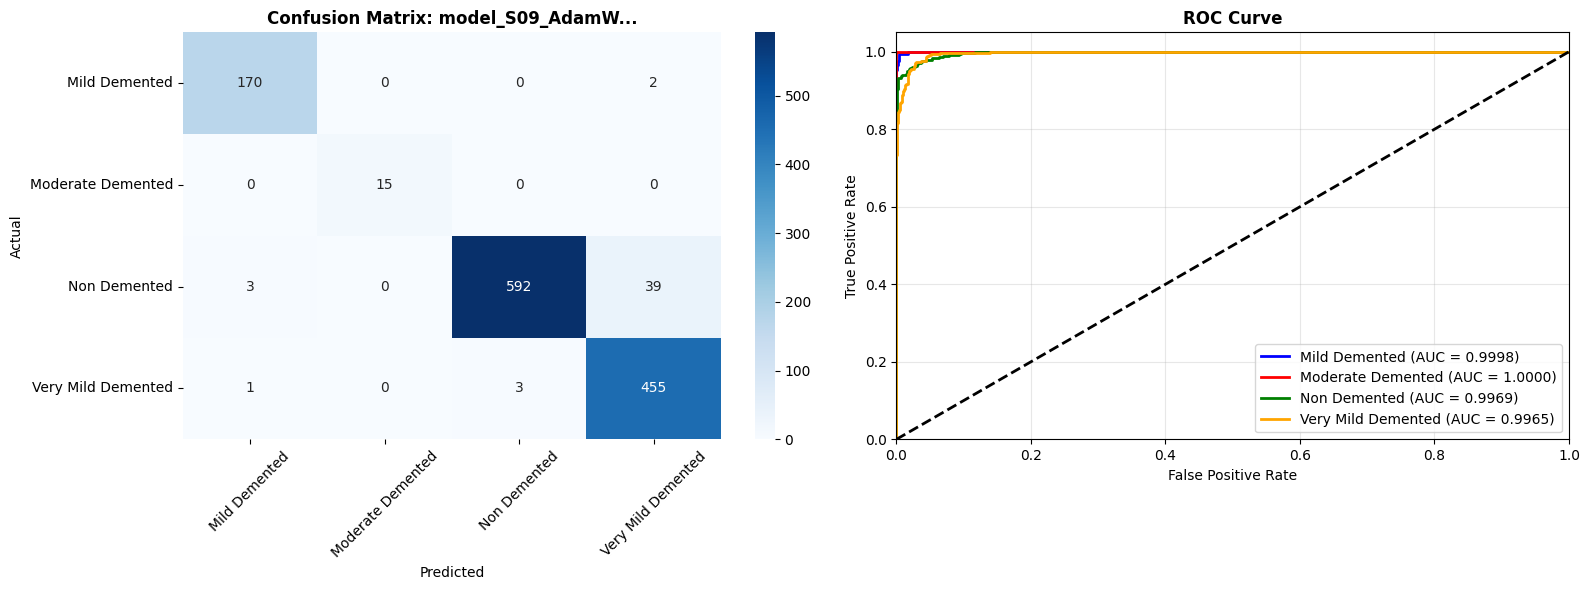


🚀 METODE: SAMPLER | MODEL: model_S10_AdamW_CosineAnnealingLR.pth

[1] CLASSIFICATION REPORT
                    precision    recall  f1-score   support

     Mild Demented     0.9235    0.9826    0.9521       172
 Moderate Demented     1.0000    1.0000    1.0000        15
      Non Demented     0.9755    0.9416    0.9583       634
Very Mild Demented     0.9383    0.9608    0.9494       459

          accuracy                         0.9547      1280
         macro avg     0.9593    0.9712    0.9649      1280
      weighted avg     0.9555    0.9547    0.9548      1280


[2] CONFUSION MATRIX & ROC CURVE


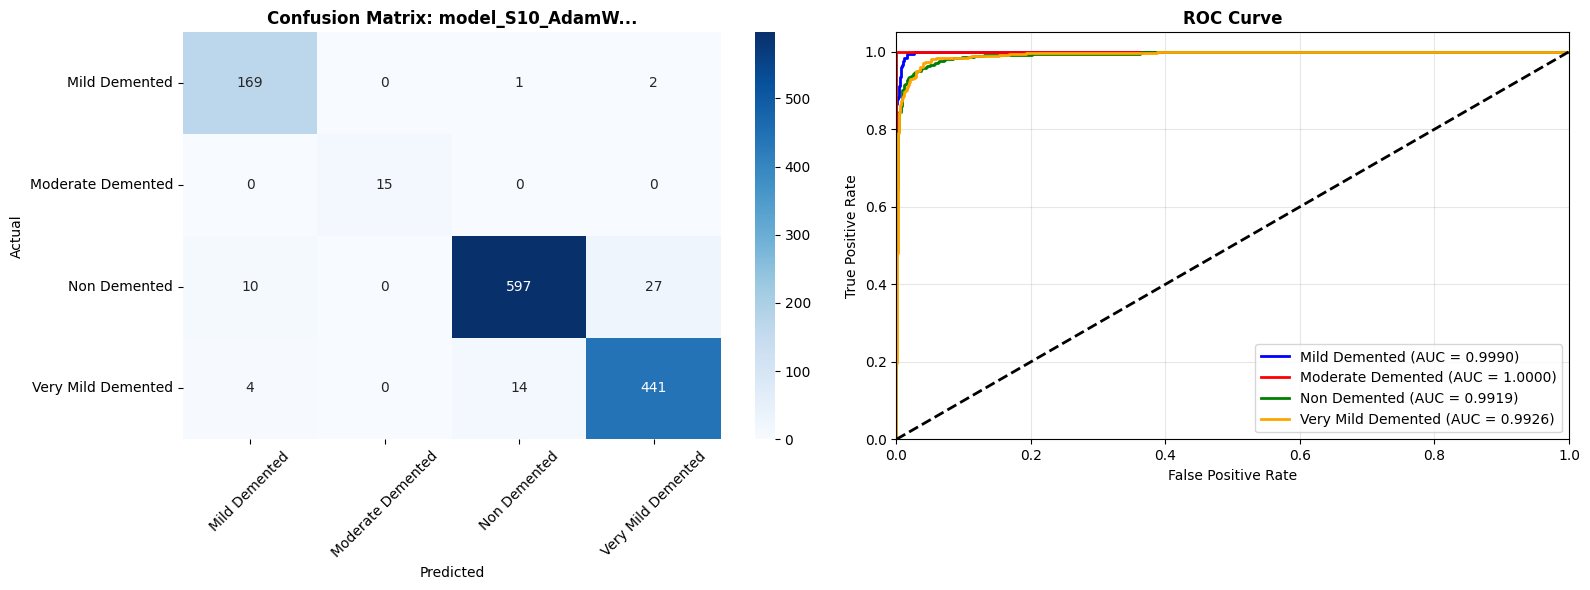


🚀 METODE: SAMPLER | MODEL: model_S11_SGD_ReduceLROnPlateau.pth

[1] CLASSIFICATION REPORT
                    precision    recall  f1-score   support

     Mild Demented     0.3003    0.6512    0.4110       172
 Moderate Demented     0.0000    0.0000    0.0000        15
      Non Demented     0.6786    0.6861    0.6824       634
Very Mild Demented     0.4792    0.2767    0.3508       459

          accuracy                         0.5266      1280
         macro avg     0.3645    0.4035    0.3610      1280
      weighted avg     0.5483    0.5266    0.5190      1280


[2] CONFUSION MATRIX & ROC CURVE


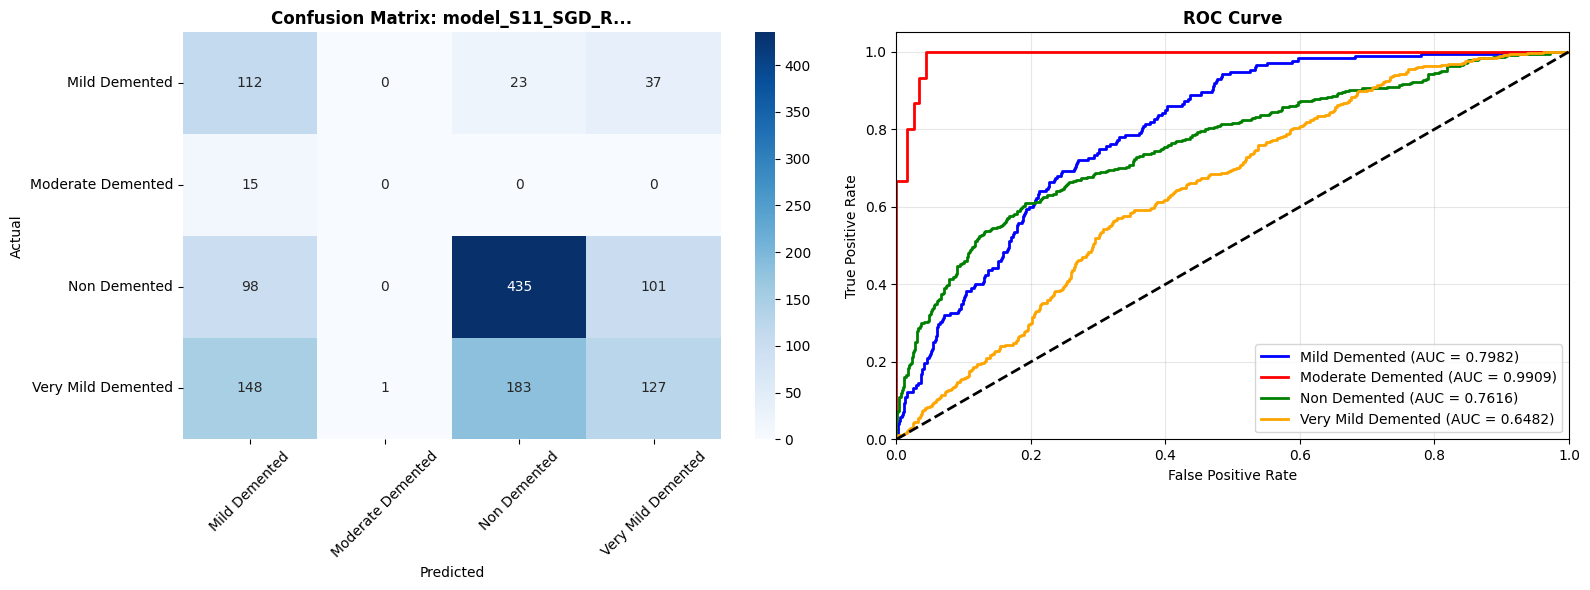


🚀 METODE: SAMPLER | MODEL: model_S12_SGD_CosineAnnealingLR.pth

[1] CLASSIFICATION REPORT
                    precision    recall  f1-score   support

     Mild Demented     0.2968    0.5349    0.3817       172
 Moderate Demented     0.0000    0.0000    0.0000        15
      Non Demented     0.6461    0.7114    0.6772       634
Very Mild Demented     0.4632    0.2745    0.3447       459

          accuracy                         0.5227      1280
         macro avg     0.3515    0.3802    0.3509      1280
      weighted avg     0.5260    0.5227    0.5103      1280


[2] CONFUSION MATRIX & ROC CURVE


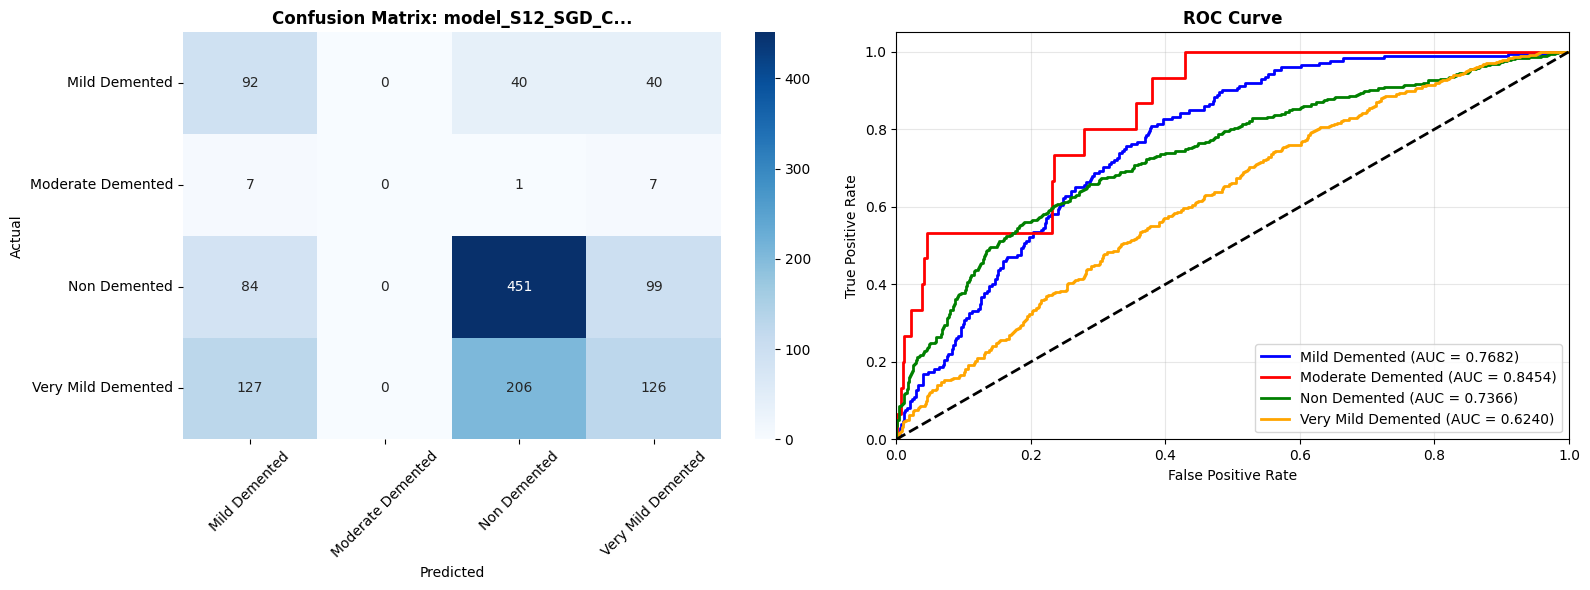


🚀 METODE: SAMPLER | MODEL: model_S13_Adam_ReduceLROnPlateau.pth

[1] CLASSIFICATION REPORT
                    precision    recall  f1-score   support

     Mild Demented     0.9706    0.9593    0.9649       172
 Moderate Demented     1.0000    1.0000    1.0000        15
      Non Demented     0.9888    0.9779    0.9833       634
Very Mild Demented     0.9658    0.9847    0.9752       459

          accuracy                         0.9781      1280
         macro avg     0.9813    0.9805    0.9809      1280
      weighted avg     0.9783    0.9781    0.9781      1280


[2] CONFUSION MATRIX & ROC CURVE


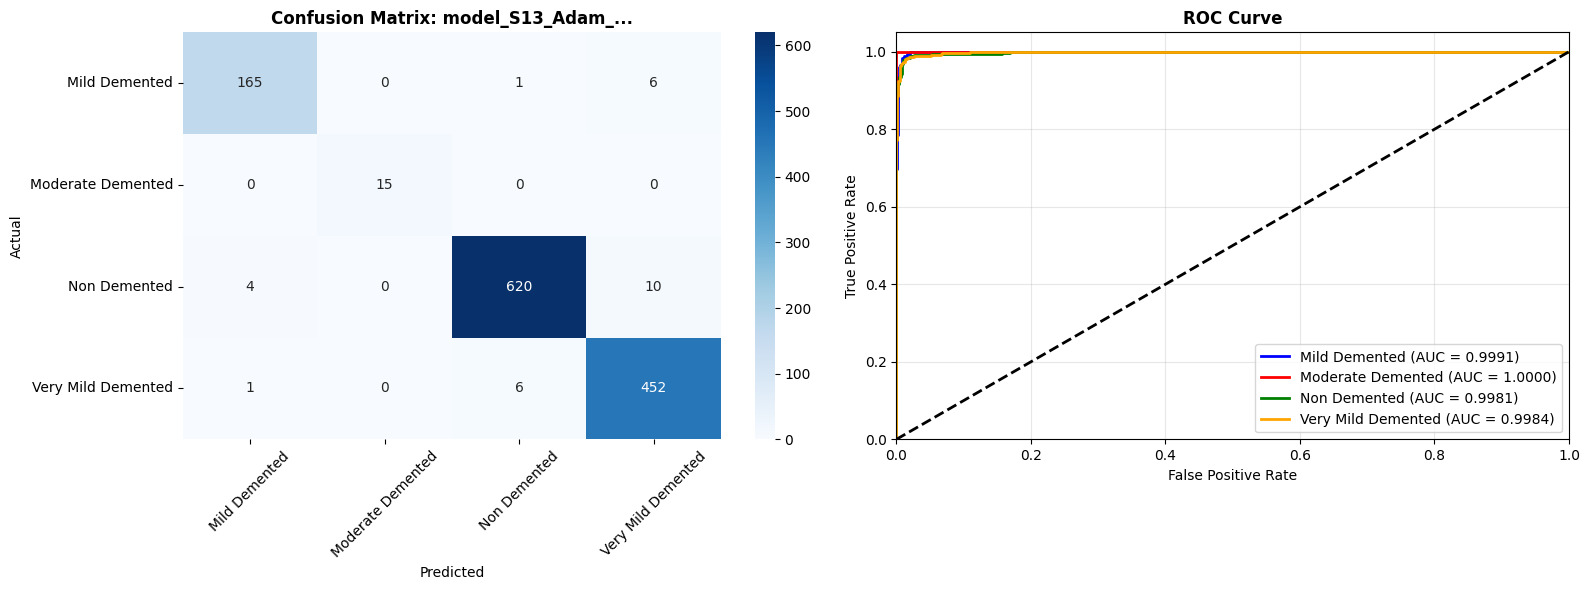


🚀 METODE: SAMPLER | MODEL: model_S14_Adam_CosineAnnealingLR.pth

[1] CLASSIFICATION REPORT
                    precision    recall  f1-score   support

     Mild Demented     0.9882    0.9709    0.9795       172
 Moderate Demented     1.0000    1.0000    1.0000        15
      Non Demented     0.9905    0.9858    0.9881       634
Very Mild Demented     0.9742    0.9869    0.9805       459

          accuracy                         0.9844      1280
         macro avg     0.9882    0.9859    0.9870      1280
      weighted avg     0.9844    0.9844    0.9844      1280


[2] CONFUSION MATRIX & ROC CURVE


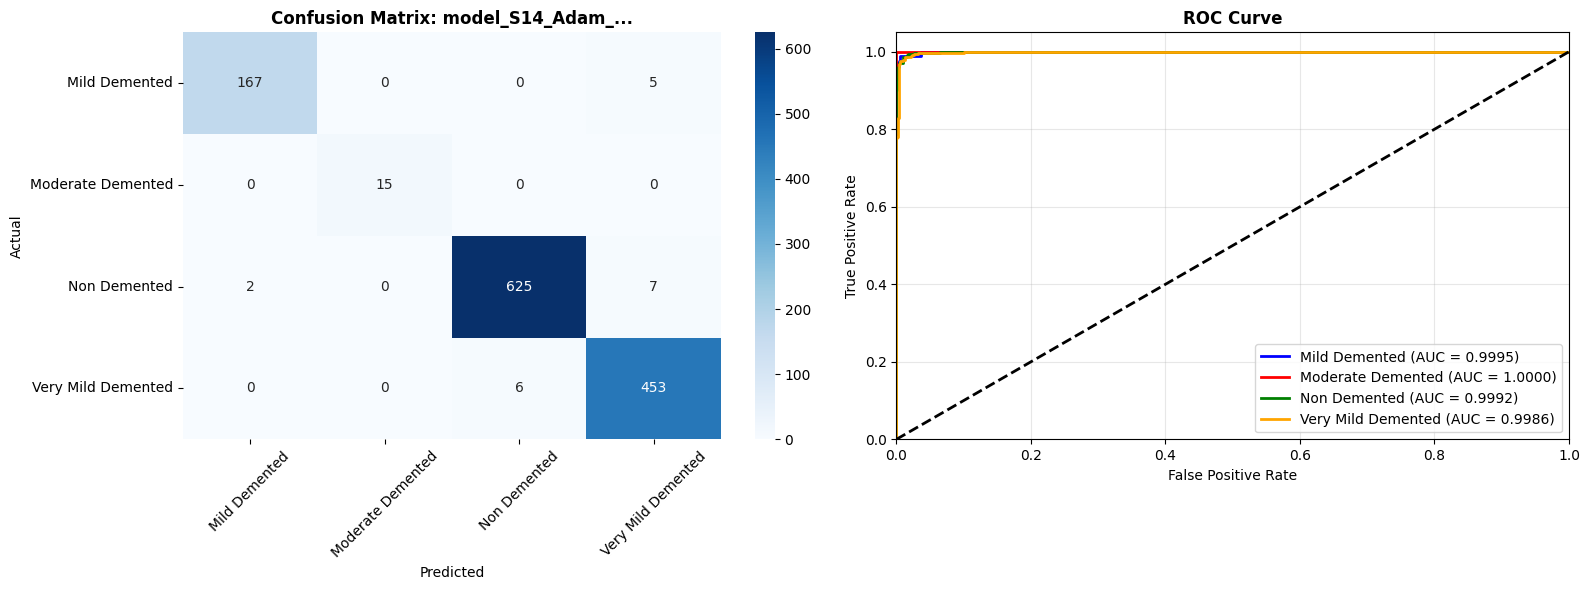


🚀 METODE: SAMPLER | MODEL: model_S15_AdamW_ReduceLROnPlateau.pth

[1] CLASSIFICATION REPORT
                    precision    recall  f1-score   support

     Mild Demented     0.9713    0.9826    0.9769       172
 Moderate Demented     1.0000    1.0000    1.0000        15
      Non Demented     0.9952    0.9732    0.9841       634
Very Mild Demented     0.9660    0.9913    0.9785       459

          accuracy                         0.9812      1280
         macro avg     0.9831    0.9868    0.9849      1280
      weighted avg     0.9816    0.9812    0.9813      1280


[2] CONFUSION MATRIX & ROC CURVE


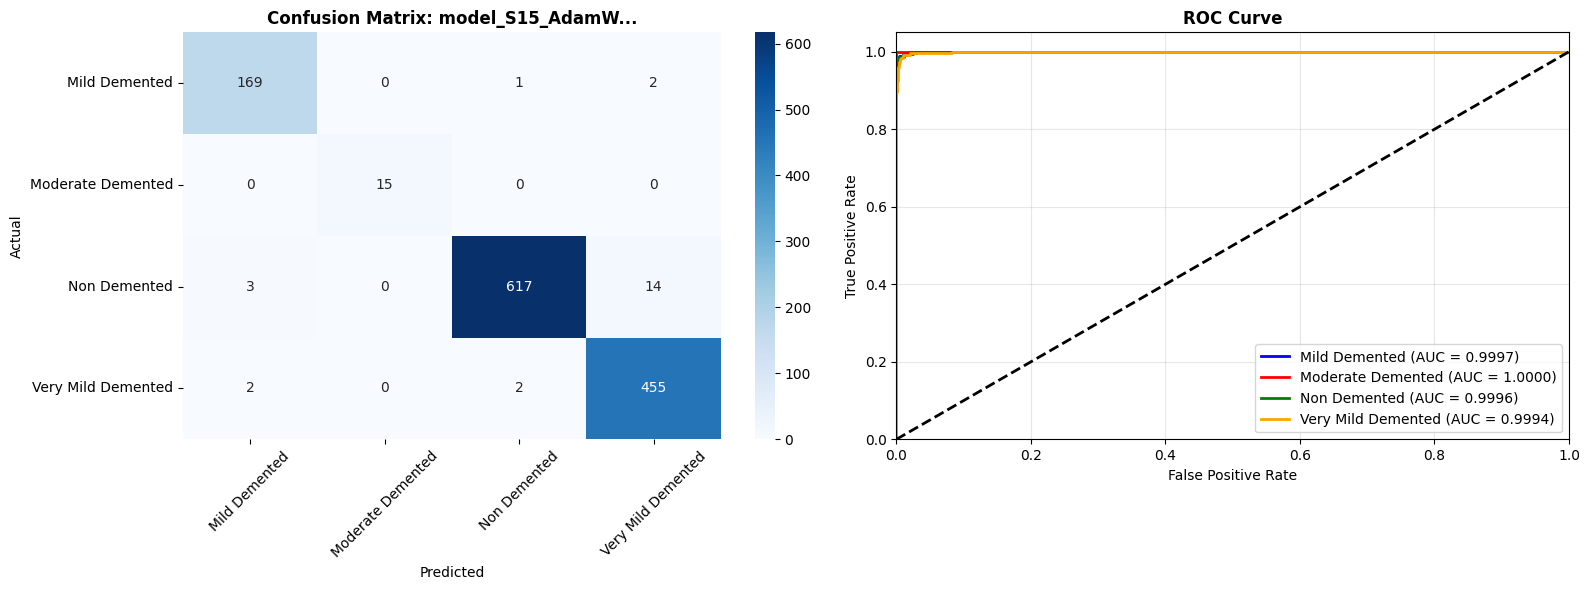


🚀 METODE: SAMPLER | MODEL: model_S16_AdamW_CosineAnnealingLR.pth

[1] CLASSIFICATION REPORT
                    precision    recall  f1-score   support

     Mild Demented     1.0000    0.9826    0.9912       172
 Moderate Demented     1.0000    1.0000    1.0000        15
      Non Demented     0.9921    0.9921    0.9921       634
Very Mild Demented     0.9870    0.9935    0.9902       459

          accuracy                         0.9914      1280
         macro avg     0.9948    0.9920    0.9934      1280
      weighted avg     0.9914    0.9914    0.9914      1280


[2] CONFUSION MATRIX & ROC CURVE


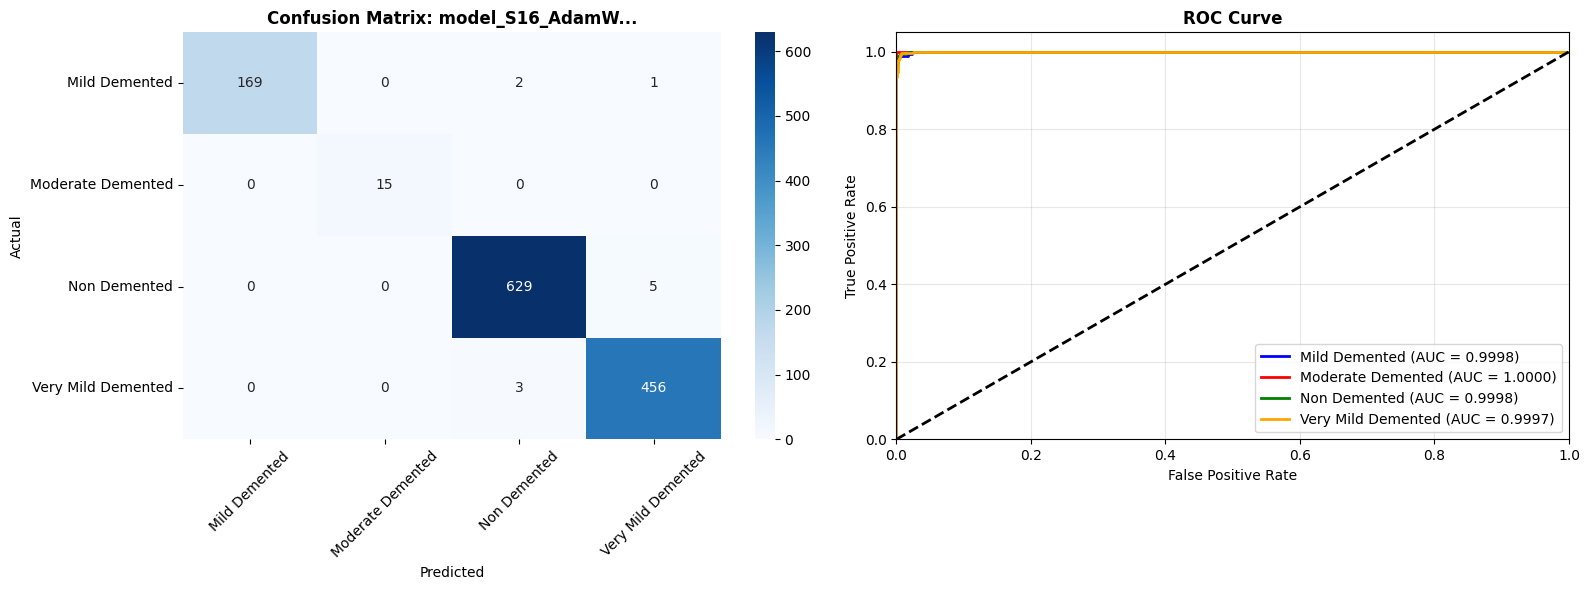


🚀 METODE: SAMPLER | MODEL: model_S17_SGD_ReduceLROnPlateau.pth

[1] CLASSIFICATION REPORT
                    precision    recall  f1-score   support

     Mild Demented     0.3275    0.7558    0.4569       172
 Moderate Demented     0.8462    0.7333    0.7857        15
      Non Demented     0.7287    0.6735    0.7000       634
Very Mild Demented     0.5528    0.3420    0.4226       459

          accuracy                         0.5664      1280
         macro avg     0.6138    0.6262    0.5913      1280
      weighted avg     0.6131    0.5664    0.5689      1280


[2] CONFUSION MATRIX & ROC CURVE


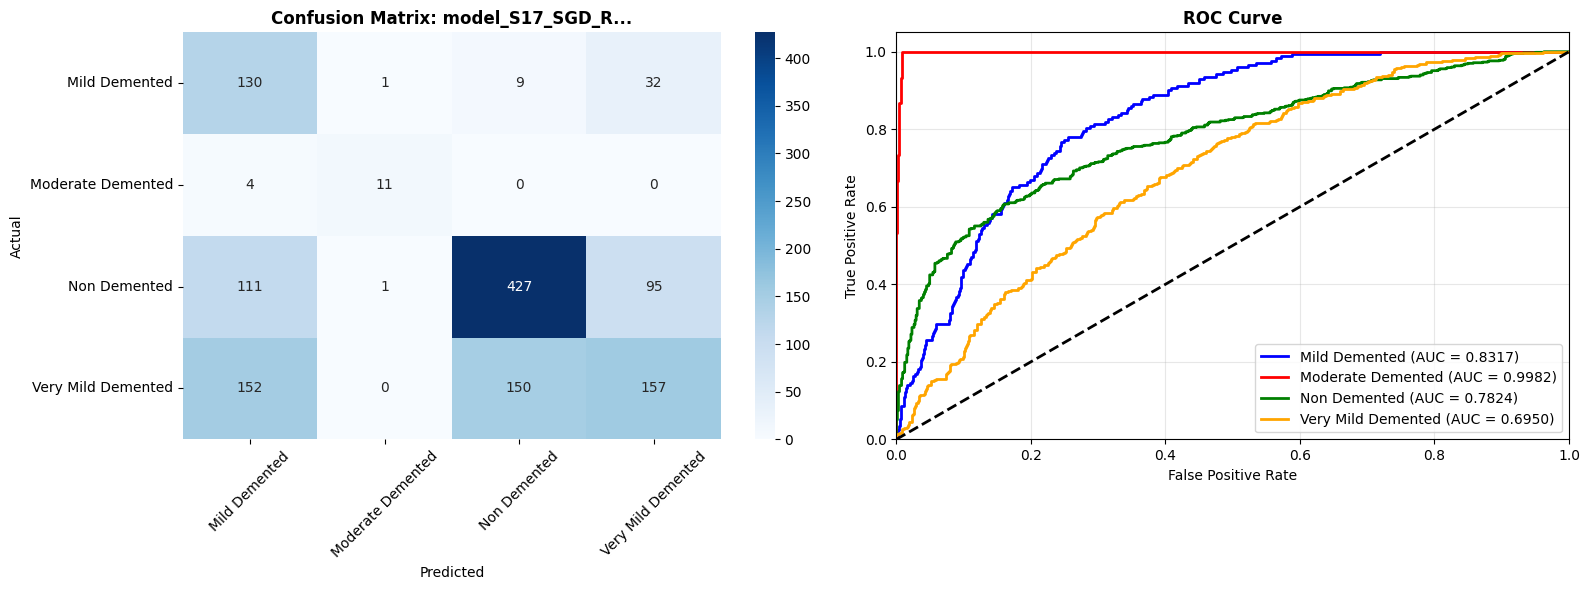


🚀 METODE: SAMPLER | MODEL: model_S18_SGD_CosineAnnealingLR.pth

[1] CLASSIFICATION REPORT
                    precision    recall  f1-score   support

     Mild Demented     0.2695    0.5814    0.3683       172
 Moderate Demented     0.0000    0.0000    0.0000        15
      Non Demented     0.6442    0.7397    0.6887       634
Very Mild Demented     0.4254    0.1678    0.2406       459

          accuracy                         0.5047      1280
         macro avg     0.3348    0.3722    0.3244      1280
      weighted avg     0.5079    0.5047    0.4769      1280


[2] CONFUSION MATRIX & ROC CURVE


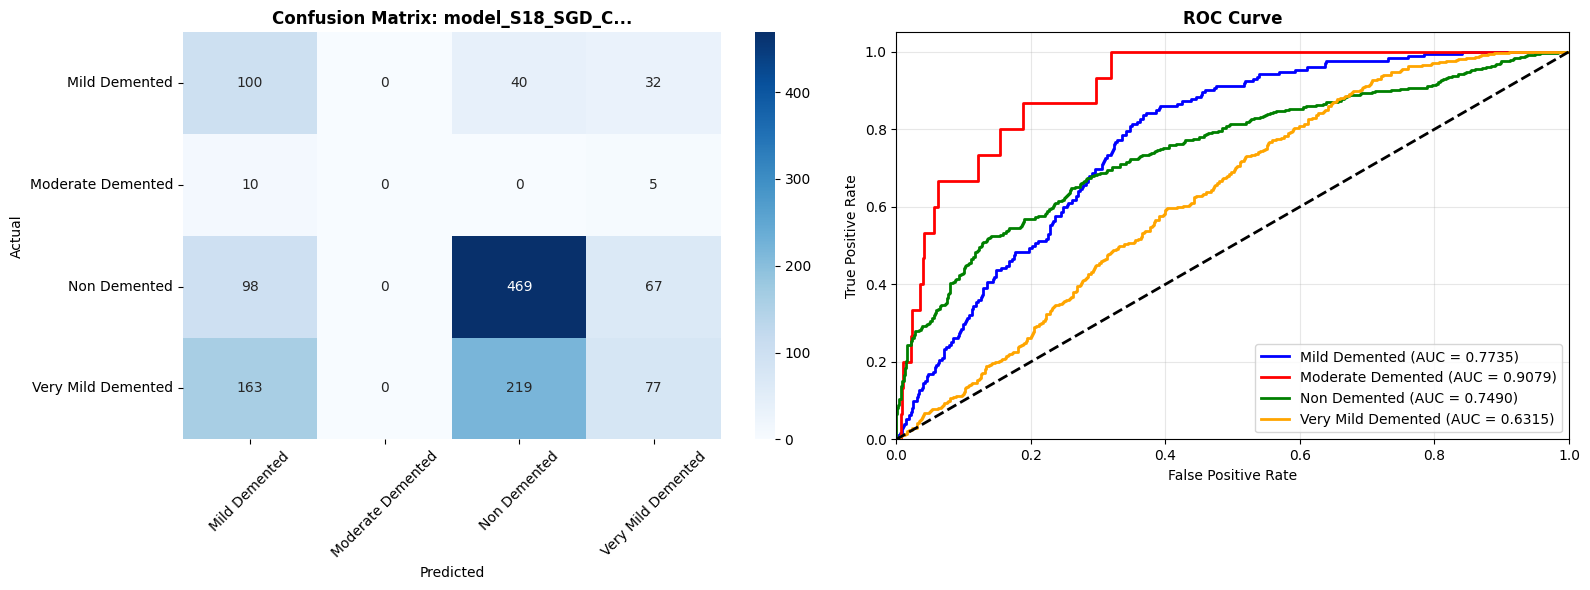

In [ ]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
import numpy as np
import torch
import torch.nn.functional as F

# Pastikan list kelas ini sesuai dengan urutan index dataset (0, 1, 2, 3)
class_names = ["Mild Demented", "Moderate Demented", "Non Demented", "Very Mild Demented"]

def evaluate_and_visualize_all(folder_path, method_name):
    if not os.path.exists(folder_path):
        print(f"Folder tidak ditemukan: {folder_path}")
        return

    model_files = [f for f in os.listdir(folder_path) if f.endswith('.pth')]
    model_files.sort() # Urutkan dari S01 sampai S18

    for filename in model_files:
        filepath = os.path.join(folder_path, filename)

        # Header pemisah antar model agar outputnya rapi
        print("\n" + "="*70)
        print(f"🚀 METODE: {method_name.upper()} | MODEL: {filename}")
        print("="*70)

        # 1. LOAD WEIGHTS
        model.load_state_dict(torch.load(filepath, map_location=device))

        # 2. INFERENCE
        all_labels = []
        all_preds = []
        all_probs = []

        with torch.no_grad():
            for images, labels in test_loader:
                images = images.to(device)
                outputs = model(images)

                probs = F.softmax(outputs, dim=1)
                preds = torch.argmax(probs, dim=1)

                all_labels.extend(labels.cpu().numpy())
                all_preds.extend(preds.cpu().numpy())
                all_probs.extend(probs.cpu().numpy())

        all_labels = np.array(all_labels)
        all_preds = np.array(all_preds)
        all_probs = np.array(all_probs)

        # 3. CLASSIFICATION REPORT
        print("\n[1] CLASSIFICATION REPORT")
        print(classification_report(all_labels, all_preds, target_names=class_names, digits=4, zero_division=0))

        # 4. CONFUSION MATRIX
        print("\n[2] CONFUSION MATRIX & ROC CURVE")
        fig, axes = plt.subplots(1, 2, figsize=(16, 6)) # Jejerkan 2 grafik kiri-kanan

        # -- Grafik Kiri: Confusion Matrix --
        cm = confusion_matrix(all_labels, all_preds)
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                    xticklabels=class_names, yticklabels=class_names, ax=axes[0])
        axes[0].set_xlabel("Predicted")
        axes[0].set_ylabel("Actual")
        axes[0].set_title(f"Confusion Matrix: {filename[:15]}...", fontweight='bold')
        axes[0].tick_params(axis='x', rotation=45)

        # -- Grafik Kanan: ROC Curve --
        y_bin = label_binarize(all_labels, classes=[0, 1, 2, 3])
        colors = ['blue', 'red', 'green', 'orange']

        for i, color in zip(range(4), colors):
            fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
            roc_auc = auc(fpr, tpr)
            axes[1].plot(fpr, tpr, color=color, lw=2,
                         label=f'{class_names[i]} (AUC = {roc_auc:.4f})')

        axes[1].plot([0, 1], [0, 1], 'k--', lw=2)
        axes[1].set_xlim([0.0, 1.0])
        axes[1].set_ylim([0.0, 1.05])
        axes[1].set_xlabel('False Positive Rate')
        axes[1].set_ylabel('True Positive Rate')
        axes[1].set_title('ROC Curve', fontweight='bold')
        axes[1].legend(loc="lower right")
        axes[1].grid(alpha=0.3)

        plt.tight_layout()
        plt.show() # Tampilkan gambar di Colab

        # SANGAT PENTING: Bebaskan memori Matplotlib setelah ditampilkan!
        plt.close('all')


# ==========================================
# EKSEKUSI UNTUK KEDUA FOLDER
# ==========================================
# Panggil untuk folder Class Weight
evaluate_and_visualize_all(FOLDER_CLASS_WEIGHT, "Class Weight")

# Panggil untuk folder Sampler
evaluate_and_visualize_all(FOLDER_SAMPLER, "Sampler")